# editing plots

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/ens.py -e RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 -v W --plotmean

In [1]:
from optparse import OptionParser
import sys
import os
import numpy as N
import numpy as np
import datetime as DT 
import netCDF4 as ncdf
import glob
import pylab as P
from datetime import datetime
from Plotting.cbook2 import nice_mxmnintvl, nice_clevels
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import ndimage

_bin_delta = 1
zbins = 2000. * N.arange(6)
radar_hgt = 373.

_prior_files = "Prior_*"
_plotfilename = "DBZ_ConsistencyRatio"

_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "REFL"   # valid variables:  VR, REFL
only_pos_dbz = True

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

kernel = N.array([[1,2,1],
                  [-2,0,-2],
                  [1,-2,1]])


## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})


In [2]:
def smfnc(x):
    return ndimage.gaussian_filter(x, sigma=0.75)
    
# ------------------------------------------------------------------------------------------
# Search functions  each returns a boolean array of T/F with the same dimensions as field

def getIndexVariable(field, variable):
    return (field == variable)
    
def getIndexGreaterThan(field, value):
    return ( field > value )
    
def getIndexLessThan(field, value):
    return ( field < value )
    
def getIndexGreaterThanOrEqual(field, value):
    return ( field >= value )
    
def getIndexLessThanOrEqual(field, value):
    return ( field <= value )

def getIndexEqual(field, value):
    return ( field == value )

def getIndexNotEqual(field, value):
    return ( field != value )


def DBZ_stats_timeseries(experiment_location, only_pos_dbz=True):
    dirname = os.path.join(experiment_location,_prior_files)
    plotfilename='DBZ_CR'
    noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)

    bin_delta = _bin_delta

    nbins = len(file_list) // bin_delta
    CR_T  = N.zeros((nbins))
    IN_T  = N.zeros((nbins))
    
    m = -1
    
    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
        
            HxfL     = []
            valueL   = []
            depL     = []
            errorL   = []
            secsL    = []
            zL       = []
            kindL    = []

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:])
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] )
        secsL.append(f.variables["secs"][:])
        errorL.append(N.sqrt(f.variables["error"][:]))
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = N.concatenate(HxfL, axis=0)
            value = N.concatenate(valueL, axis=0)
            z     = N.concatenate(zL, axis=0)
            dep   = N.concatenate(depL, axis=0)
            secs  = N.concatenate(secsL, axis=0)
            error = N.concatenate(errorL, axis=0)
            kind  = N.concatenate(kindL, axis=0)
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m = m + 1

            if only_pos_dbz:
                index_kind  = getIndexVariable(kind,variable)
                index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                index       = index_kind & index_pos
            else:
                index = getIndexVariable(kind,variable)
       
            if N.sum(index == True) > 2: 
                d           = dep[index]
                obs_var     = error[index]
                Hxftmp      = Hxf[index,:]
                Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
                inno_var    = N.mean((d - d.mean())**2)
                consi_ratio = (obs_var[1]**2 + Hxf_var) / inno_var
                CR_T[m] = consi_ratio
                IN_T[m] = d.mean()
      
        f.close()

    return datebins, CR_T, IN_T


def format_time_ticks(ax, dates, minute_interval=10, approx_number_of_ticks=8,  tick_format='%H:%M', rotation=30, fontsize=14):
    ''' This does basic formatting to help clean up the plot cells'''

    start = dates[0]
    end   = dates[-1]
    ax.set_xlim(start, end)
    nticks_approx = 8
    minute_interval = 5*round((end-start).seconds/(approx_number_of_ticks*60*5)) #find the best interval divisble by 5 based on nticks
    maj_loc = mdates.MinuteLocator(interval=minute_interval)
    ax.xaxis.set_major_locator(maj_loc)
    dateFmt = mdates.DateFormatter(tick_format)
    ax.xaxis.set_major_formatter(dateFmt)
    labels = ax.get_xticklabels()
    plt.setp(labels, rotation=30, fontsize=14)

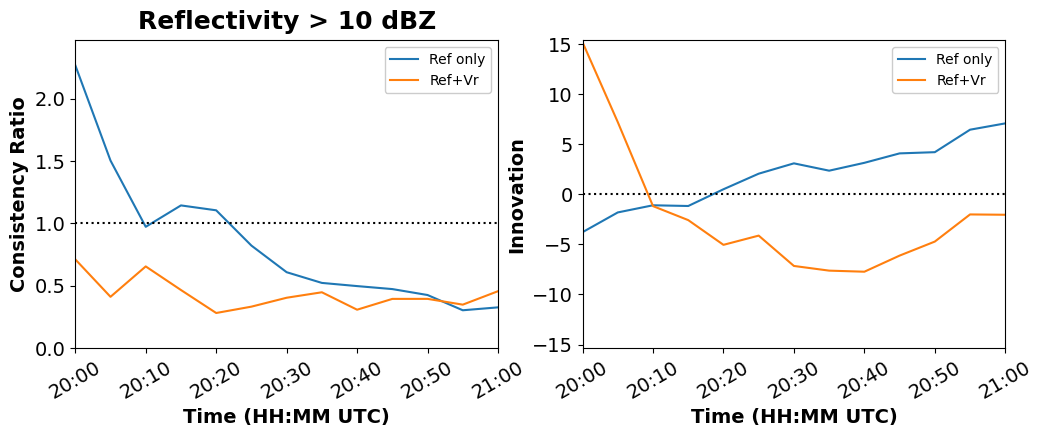

In [4]:
labels = ['Ref only', 'Ref+Vr']

fig,axes = plt.subplots(1,2, figsize=(12,4))

cr_arr = []
in_arr = []
for i,exp in enumerate(['DBZ_only', 'DBZ_VR']):

    dates, CR, IN = DBZ_stats_timeseries(exp, only_pos_dbz=True)
    cr_arr.append(np.max(CR))
    in_arr.append(np.max(abs(IN)))
    axes[0].plot(dates, CR, label=labels[i])
    axes[1].plot(dates, IN, label=labels[i])

for ax in axes.flatten():
    ax.legend()
    format_time_ticks(ax, dates)
    
    ax.set_xlabel('Time (HH:MM UTC)')
axes[0].set_title('Reflectivity > 10 dBZ', weight='bold', y=1.01)

axes[0].set_ylabel("Consistency Ratio")
axes[1].set_ylabel("Innovation")
# axes[0].set_ylim(0,2.5)
# axes[0].set_ylim(0,2.5)

axes[0].set_ylim(0, np.max(cr_arr)+.2)
axes[1].set_ylim(np.max(in_arr)*-1 -.2, np.max(in_arr)+.2,)

axes[0].axhline(1, ls=':', color='k')
axes[1].axhline(0, ls=':', color='k')

['RUN_LETKF/Prior_2024-05-08_20:00:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:05:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:10:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:15:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:20:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:25:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:30:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:35:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:40:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:45:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:50:00.nc', 'RUN_LETKF/Prior_2024-05-08_20:55:00.nc', 'RUN_LETKF/Prior_2024-05-08_21:00:00.nc']

First file:  RUN_LETKF/Prior_2024-05-08_20:00:00.nc
Last file:   RUN_LETKF/Prior_2024-05-08_21:00:00.nc


 2D CONSISTENCY RATIO CALCULATIONS......

55.506134033203125 10.14350700378418
2024-05-08_20:00:00  NOBS: 00054     VR: 7.0  ZBIN:  0.000000  2000.000000  RMSI: 12.298  M-Innov:   1.069  Spread:  9.348  CRatio:  0.5778 
55.506134033203125 10.14350700378418
2024-05-08_20:00:00  NOBS: 00054     VR: 7.0  ZBIN:  2000.000000  4000.000000  RMSI: 12.2

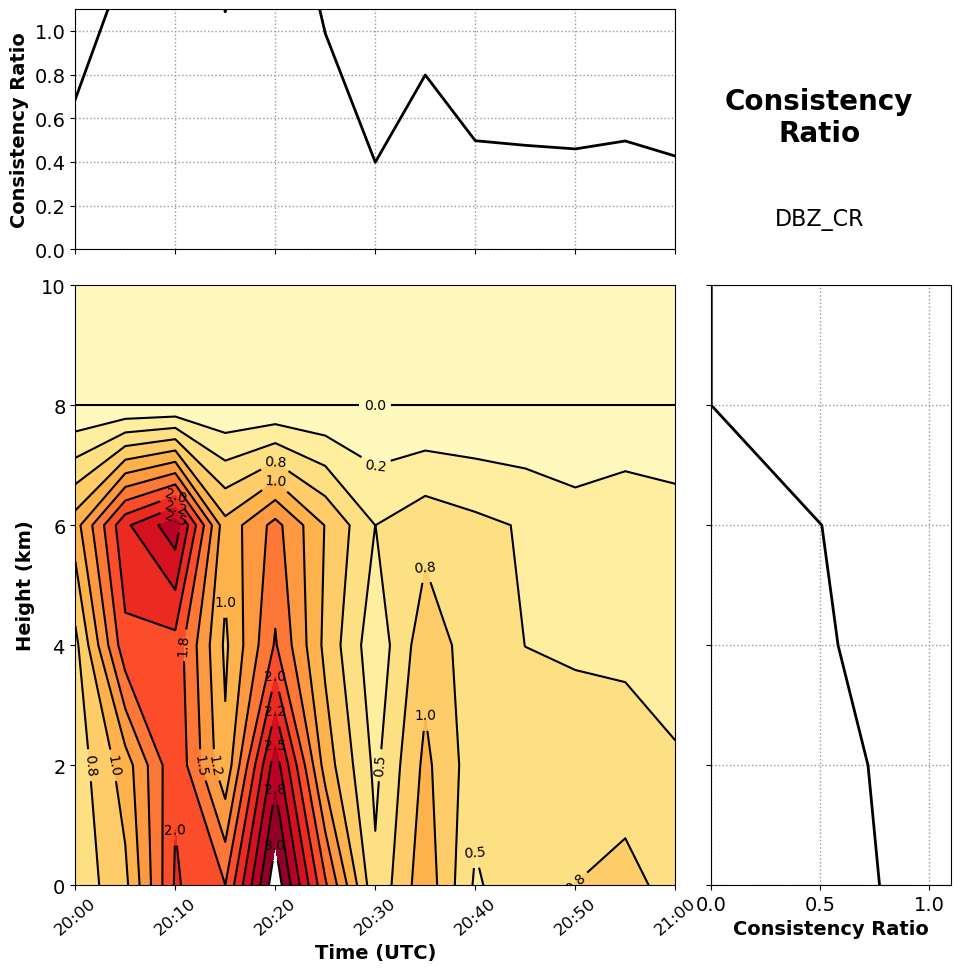

In [7]:
#####################################################################################################
# Main program
test=True
if test == True:

    # print("\n<<<<<===========================================================================================>>>>>>")
    # print("\n\n    CONSISTENCY RATIO PLOT       \n\n")

    # usage = "usage: %prog [options] arg"
    # parser = OptionParser(usage)

    # parser.add_option("-d",  "--dir",    dest="dir",  type="string", help="Name of directory where Prior files are")
    # parser.add_option("-t",  "--title",  dest="title", type="string", help="Name of plot and used as the name of the outputfile")
    # parser.add_option(       "--noshow",  dest="noshow", default=False, action="store_true", help="Turn off screen plotting")

    # (options, args) = parser.parse_args()

    # if options.dir:
    #   dirname = os.path.join(options.dir,_prior_files)
    # else:
    #   print("\n  ====>  No directory supplied, using %s as prefix \n" % _prior_files)
    #   dirname = os.path.join("./",_prior_files)

    # if options.title:
    #   plotfilename = options.title
    # else:
    #   plotfilename = _plotfilename
    dirname = os.path.join('RUN_LETKF',_prior_files)
    plotfilename='DBZ_CR'
    noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)
    print(file_list)

    print("\nFirst file:  %s" % file_list[0])
    print("Last file:   %s\n" % file_list[-1])

    bin_delta = _bin_delta

    nbins = len(file_list) // bin_delta
    CR_TZ = N.zeros((zbins.size,nbins))
    CR_T  = N.zeros((nbins))
    CR_Z  = N.zeros((zbins.size))
    m = -1
    
    fig = P.figure(figsize=(12,12))
    fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
    fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")

    print("\n 2D CONSISTENCY RATIO CALCULATIONS......\n")
    
    datebins = []
    secsbins = []

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
        
            HxfL     = []
            depL     = []
            errorL   = []
            secsL    = []
            zL       = []
            kindL    = []
            valueL   = []

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:])
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] )
        secsL.append(f.variables["secs"][:])
        errorL.append(N.sqrt(f.variables["error"][:]))
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = N.concatenate(HxfL, axis=0)
            value = N.concatenate(valueL, axis=0)
            z     = N.concatenate(zL, axis=0)
            dep   = N.concatenate(depL, axis=0)
            secs  = N.concatenate(secsL, axis=0)
            error = N.concatenate(errorL, axis=0)
            kind  = N.concatenate(kindL, axis=0)
            #datebins.append((ncdf.num2date(secs[1],units=sec_utime)).strftime("%Y%m%d%H%M%S"))
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m = m + 1

            index_kind  = getIndexVariable(kind,variable)
            index_pos   = getIndexGreaterThanOrEqual(value, 10.0)

            for k in N.arange(zbins.size-1):
                index1                = getIndexGreaterThanOrEqual(z, zbins[k])
                index2                = getIndexLessThan(z, zbins[k+1])

                if only_pos_dbz:
                    index             = index_kind & index1 & index2 & index_pos
                else:
                    index             = index_kind & index1 & index2

                if N.sum(index == True) > 2: 
                    v           = value[index]
                    print(v.max(), v.min())
                    d           = dep[index]
                    obs_var     = error[index]
                    Hxftmp      = Hxf[index,:]
                    Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
                    inno_var    = N.mean((d - d.mean())**2)
                    consi_ratio = (obs_var[1]**2 + Hxf_var) / inno_var
                    print("%s  NOBS: %5.5d    %3.3s: %3.1f  ZBIN:  %f  %f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                    % (file[-22:-3], d.size, "VR", obs_var[1], zbins[k], zbins[k+1], \
                    N.sqrt(inno_var), d.mean(), N.sqrt(obs_var[1]**2 + Hxf_var), consi_ratio))
                    CR_TZ[k,m] = consi_ratio
          
        f.close()

# Plotting

    axC = P.axes(rectC)

    zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
    zmin = 0.0

    if auto_clevels:
        cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.25)
    else:
        clevels = N.arange(spread_limits[0], spread_limits[1], spread_limits[2])

    cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap='YlOrRd')
    #axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
    cs2=axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k')

    start = datebins[0]
    end   = datebins[-1]
    
    nticks_approx = 8
    minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks
    
    axC.set_xlim(start, end)
    axC.set_ylim(zmin,zmax)
    
    maj_loc = mdates.MinuteLocator(interval=minute_interval)
    axC.xaxis.set_major_locator(maj_loc)
    dateFmt = mdates.DateFormatter('%H:%M')
    axC.xaxis.set_major_formatter(dateFmt)
    
    labels = axC.get_xticklabels()
    P.setp(labels, rotation=40, fontsize=12)
    
    axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
    axC.set_ylabel("Height (km)", weight='bold')
    axC.set_xlabel("Time (UTC)",weight='bold')

#===================================================================================================
# time series Consistency Ratio

    print("\n TIME-SERIES CONSISTENCY RATIO CALCULATIONS......\n")

    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
        
            HxfL     = []
            valueL   = []
            depL     = []
            errorL   = []
            secsL    = []
            zL       = []
            kindL    = []

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:])
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] )
        secsL.append(f.variables["secs"][:])
        errorL.append(N.sqrt(f.variables["error"][:]))
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = N.concatenate(HxfL, axis=0)
            value = N.concatenate(valueL, axis=0)
            z     = N.concatenate(zL, axis=0)
            dep   = N.concatenate(depL, axis=0)
            secs  = N.concatenate(secsL, axis=0)
            error = N.concatenate(errorL, axis=0)
            kind  = N.concatenate(kindL, axis=0)
            #datebins.append((ncdf.num2date(secs[1],units=sec_utime)).strftime("%Y%m%d%H%M%S"))
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m = m + 1

            if only_pos_dbz:
                index_kind  = getIndexVariable(kind,variable)
                index_pos   = getIndexGreaterThanOrEqual(value, 10.0)
                index       = index_kind & index_pos
            else:
                index = getIndexVariable(kind,variable)
       
            if N.sum(index == True) > 2: 
                d           = dep[index]
                obs_var     = error[index]
                Hxftmp      = Hxf[index,:]
                Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
                inno_var    = N.mean((d - d.mean())**2)
                consi_ratio = (obs_var[1]**2 + Hxf_var) / inno_var
                print("%s  NOBS: %5.5d    %3.3s: %3.1f  ZBIN:  %f  %f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (file[-22:-3], d.size, "VR", obs_var[1], 0.0, zbins.max(), \
                N.sqrt(inno_var), d.mean(), N.sqrt(obs_var[1]**2 + Hxf_var), consi_ratio))
                CR_T[m] = consi_ratio
      
        f.close()

# Plotting

    axX = P.axes(rectX)
#   cmin, cmax, cint = nice_mxmnintvl(CR_T.min(), CR_T.max(), outside=True, cint=1.0)  # Use this to get limits of the plot
    s = datebins[0]
    e = datebins[-1]
    axX.plot(datebins, CR_T, lw=2.0, color='k')
    axX.set_xlim(s, e)
    axX.set_ylim(_cmin, _cmax)
    axX.set_xticklabels([])
    axX.set_ylabel("Consistency Ratio")
    axX.grid(True)

    maj_loc = mdates.MinuteLocator(interval=10)

#===================================================================================================
# Height Consistency Ratio
    
    print("\n ZBIN-D CONSISTENCY RATIO CALCULATIONS......\n")

    datebins = []
    secsbins = []
    m = -1
        
    HxfL     = []
    depL     = []
    errorL   = []
    secsL    = []
    zL       = []
    kindL    = []
    valueL   = []

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        HxfL.append(f.variables["Hxf"][:])
        valueL.append(f.variables["value"][:])
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] )
        secsL.append(f.variables["secs"][:])
        errorL.append(N.sqrt(f.variables["error"][:]))
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        f.close()

    Hxf   = N.concatenate(HxfL, axis=0)
    z     = N.concatenate(zL, axis=0)
    dep   = N.concatenate(depL, axis=0)
    secs  = N.concatenate(secsL, axis=0)
    error = N.concatenate(errorL, axis=0)
    kind  = N.concatenate(kindL, axis=0)
    value = N.concatenate(valueL, axis=0)

    if only_pos_dbz:
        index_k     = getIndexVariable(kind,variable)
        index_pos   = getIndexGreaterThanOrEqual(value, 10.0)
        index_kind  = index_k & index_pos
    else:
        index_kind = getIndexVariable(kind,variable)
       
    for k in N.arange(zbins.size-1):
        index1                = getIndexGreaterThanOrEqual(z, zbins[k])
        index2                = getIndexLessThan(z, zbins[k+1])
        index                 = index_kind & index1 & index2
        if N.sum(index == True) > 2: 
            d           = dep[index]
            obs_var     = error[index]
            Hxftmp      = Hxf[index,:]
            Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
            inno_var    = N.mean((d - d.mean())**2)
            consi_ratio = (obs_var[1]**2 + Hxf_var) / inno_var
            print("%s  NOBS: %5.5d    %3.3s: %3.1f  ZBIN:  %05.0f  %05.5f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
            % (file[-22:-3], d.size, "VR", obs_var[1], zbins[k], zbins[k+1], \
            N.sqrt(inno_var), d.mean(), N.sqrt(obs_var[1]**2 + Hxf_var), consi_ratio))
            CR_Z[k] = consi_ratio
    
# Plotting
  
    axY = P.axes(rectY)
#   cmin, cmax, cint = nice_mxmnintvl(CR_Z.min(), CR_Z.max(), outside=True, cint=1.0)  # Use this to get limits of the plot
    
    axY.plot(CR_Z, zbins/1000., lw=2.0, color='k')
    axY.set_ylim(0.0,zbins.max()/1000.)
    axY.set_xlim(_cmin,_cmax)
    axY.set_yticklabels([])
    axY.set_xlabel("Consistency Ratio")
    axY.grid(True)
    
#===================================================================================================
# SAVE FILE AND SHOW PLOT

    # P.savefig(plotfilename+".pdf")
    # if not options.noshow:
    #     P.show()



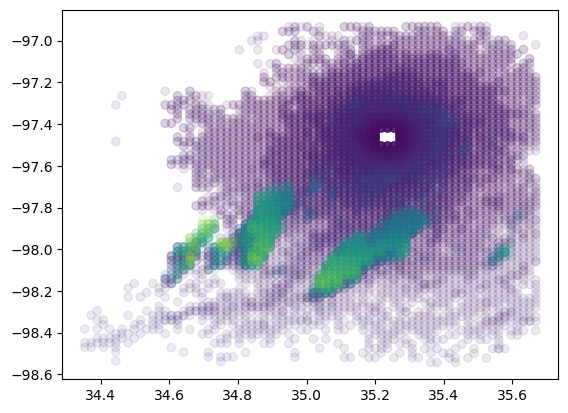

In [46]:
P.scatter(f['lat'][:], f['lon'][:], c=f['z'][:], alpha=0.1)

In [80]:
(ncdf.num2date(secs[1],units=sec_utime))#.to_datetimeindex()

cftime.DatetimeGregorian(2003, 5, 8, 21, 57, 43, 0, has_year_zero=False)

In [119]:
DT.datetime.utcfromtimestamp(secs[1])

datetime.datetime(2003, 5, 8, 20, 57, 31)

In [82]:
sec_utime

'seconds since 1970-01-01 00:00:00'

In [4]:
datebins = []
secsbins = []

m=-1
for n, file in enumerate(file_list):

    f = ncdf.Dataset(file)
    print(file)

    if n % bin_delta == 0:
        HxfL     = []
        depL     = []
        errorL   = []
        secsL    = []
        zL       = []
        kindL    = []

    HxfL.append(f.variables["Hxf"][:])
    zL.append(f.variables["z"][:] - radar_hgt)
    depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] )
    secsL.append(f.variables["secs"][:])
    errorL.append(N.sqrt(f.variables["error"][:]))
    kindL.append(f.variables["kind"][:])

    if n % bin_delta == bin_delta-1:
        Hxf   = N.concatenate(HxfL, axis=0)
        z     = N.concatenate(zL, axis=0)
        dep   = N.concatenate(depL, axis=0)
        secs  = N.concatenate(secsL, axis=0)
        error = N.concatenate(errorL, axis=0)
        kind  = N.concatenate(kindL, axis=0)
        datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))#.strftime("%Y%m%d%H%M%S")

        m = m + 1

        index_kind  = getIndexVariable(kind,variable)
   
        for k in N.arange(zbins.size-1):
            index1                = getIndexGreaterThanOrEqual(z, zbins[k])
            index2                = getIndexLessThan(z, zbins[k+1])
            index                 = index_kind & index1 & index2
            if N.sum(index == True) > 2: 
                d           = dep[index]
                obs_var     = error[index]
                Hxftmp      = Hxf[index,:]
                Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
                inno_var    = N.mean((d - d.mean())**2)
                consi_ratio = (obs_var[1]**2 + Hxf_var) / inno_var
                print("%s  NOBS: %5.5d    %3.3s: %3.1f  ZBIN:  %f  %f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (file[-22:-3], d.size, "VR", obs_var[1], zbins[k], zbins[k+1], \
                N.sqrt(inno_var), d.mean(), N.sqrt(obs_var[1]**2 + Hxf_var), consi_ratio))
                CR_TZ[k,m] = consi_ratio
      
    f.close()

RUN_LETKF/Prior_2003-05-08_21:00:00.nc
2003-05-08_21:00:00  NOBS: 06422     VR: 2.0  ZBIN:  0.000000  2000.000000  RMSI:  3.430  M-Innov:   1.138  Spread:  2.253  CRatio:  0.4312 
2003-05-08_21:00:00  NOBS: 00719     VR: 2.0  ZBIN:  2000.000000  4000.000000  RMSI:  4.943  M-Innov:   5.941  Spread:  3.194  CRatio:  0.4174 
2003-05-08_21:00:00  NOBS: 00550     VR: 2.0  ZBIN:  4000.000000  6000.000000  RMSI:  5.056  M-Innov:   5.215  Spread:  3.340  CRatio:  0.4363 
2003-05-08_21:00:00  NOBS: 00262     VR: 2.0  ZBIN:  6000.000000  8000.000000  RMSI:  4.749  M-Innov:   3.950  Spread:  4.235  CRatio:  0.7953 
2003-05-08_21:00:00  NOBS: 00074     VR: 2.0  ZBIN:  8000.000000  10000.000000  RMSI:  5.056  M-Innov:   5.662  Spread:  5.720  CRatio:  1.2803 
RUN_LETKF/Prior_2003-05-08_21:05:00.nc
2003-05-08_21:05:00  NOBS: 05746     VR: 2.0  ZBIN:  0.000000  2000.000000  RMSI:  2.457  M-Innov:   0.594  Spread:  2.153  CRatio:  0.7676 
2003-05-08_21:05:00  NOBS: 00658     VR: 2.0  ZBIN:  2000.00000

In [87]:
datebins 

[datetime.datetime(2003, 5, 8, 21, 0, 8, 37266),
 datetime.datetime(2003, 5, 8, 21, 5, 52, 276069),
 datetime.datetime(2003, 5, 8, 21, 10, 29, 421998),
 datetime.datetime(2003, 5, 8, 21, 14, 46, 503501),
 datetime.datetime(2003, 5, 8, 21, 20, 0, 412240),
 datetime.datetime(2003, 5, 8, 21, 25, 36, 70770),
 datetime.datetime(2003, 5, 8, 21, 30, 34, 163707),
 datetime.datetime(2003, 5, 8, 21, 34, 50, 761131),
 datetime.datetime(2003, 5, 8, 21, 39, 47, 848036),
 datetime.datetime(2003, 5, 8, 21, 45, 1, 293092),
 datetime.datetime(2003, 5, 8, 21, 50, 12, 119938),
 datetime.datetime(2003, 5, 8, 21, 55, 21, 13365),
 datetime.datetime(2003, 5, 8, 22, 0, 0, 822346)]

In [126]:
CR_TZ.max()

np.float64(2.4251849058778547)

/tmp/ipykernel_1466515/2940125403.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))


Text(0.5, 0, 'Time (UTC)')

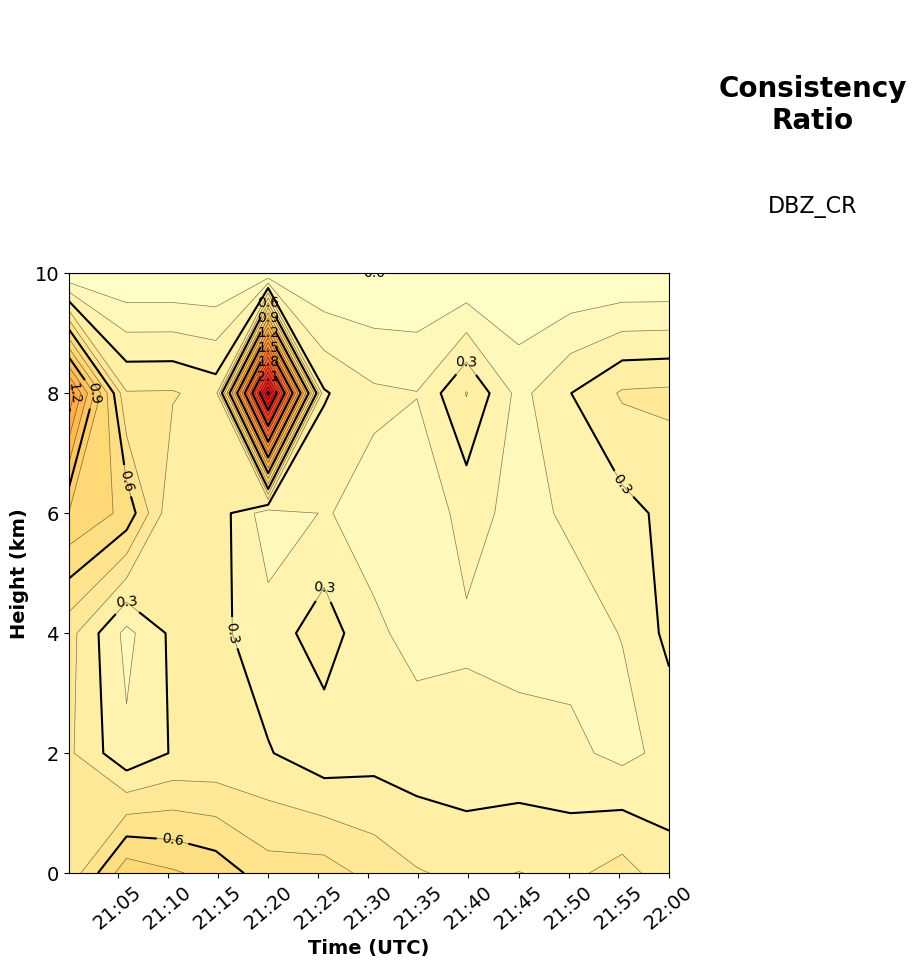

In [5]:
_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "VR"   # valid variables:  VR, DBZ
variable = 11   # valid variables:  VR, DBZ

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

fig = P.figure(figsize=(12,12))
fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")


axC = P.axes(rectC)

zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
zmin = 0.0

if auto_clevels:
    cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.1)
else:
    clevels = N.arange(spread_limits[0], spread_limits[1], spread_limits[2])

cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))
axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
cs2=axC.contour(datebins,  zbins/1000., CR_TZ, cs1.levels[::3], colors='k')

start = datebins[0]
end   = datebins[-1]

nticks_approx = 8
minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks

axC.set_xlim(start, end)
axC.set_ylim(zmin,zmax)

maj_loc = mdates.MinuteLocator(interval=minute_interval)
axC.xaxis.set_major_locator(maj_loc)
dateFmt = mdates.DateFormatter('%H:%M')
axC.xaxis.set_major_formatter(dateFmt)

labels = axC.get_xticklabels()
P.setp(labels, rotation=40, fontsize=14)

axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
axC.set_ylabel("Height (km)", weight='bold')
axC.set_xlabel("Time (UTC)",weight='bold')

# ens stuff

In [116]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

In [1]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state


#!/usr/bin/env python
#
# Version 3 of ENS - CM1 version
#


#-----------------------------------------------------------------------------------------------------------------------------
# Debug settings

debug        = False
debug_io     = False
debug_coords = False
time_all     = True

#-----------------------------------------------------------------------------------------------------------------------------
# Mapping parameters

_truelat1, _truelat2 = 30.0, 60.0

#-----------------------------------------------------------------------------------------------------------------------------
# Plotting defaults for 4 panel plots

#try:
#  from Plotting import shapefiles
#except:
#  print("\n Cannot import shapefiles....")
#  shapefiles = None

# Use a blue-->red diverging cmap to represent neg/pos fields

ens_default_cmap = P.get_cmap('seismic')

_missing = 9900000000.
_dbz_min = 0.0
_dbz_max = 75.

_clevels = {'DBZ':[5,75,5], 'W':[-10,11,1], 'TH':[295.,325.,1.], 'THP':[-5,6,0.5], 'QV':[0.0,0.022,0.002], \
            'WZ': [-100.,120.,20.], 'U':[-20,22,2], 'V':[-20,22,2]}

#-----------------------------------------------------------------------------------------------------------------------------
def run_unix_cmd(cmd):
        p = Popen(cmd, shell=True, stdout=PIPE)
        output = p.communicate()[0]
        return output

#-----------------------------------------------------------------------------------------------------------------------------
def meshgrid_general(*args):
   args = map(N.asarray,args)
   return N.broadcast_arrays(*[x[(slice(None),)+(None,)*i] for i, x in enumerate(args)])

#=======================================================================================================================
# Find the CM1 file for time requested

def FindRestartFiles(exper_filename, myDT, ret_exp=True, ret_DT=True):

# Open pickled experiment filename

    if type(exper_filename) == dict:
        exper = exper_filename
    else:
        with open(exper_filename, 'rb') as p:
            exper = json.load(p)

# Figure out how myDT is being passed, and then convert to DT object

    if type(myDT) == str:
        myDT = [int(t) for t in myDT.split(",")]
    
    if type(myDT) == list:
        myDT = datetime.datetime(myDT[0],myDT[1],myDT[2],myDT[3],myDT[4],myDT[5])
        
    print("\n ==> FindRestartFiles: Date and time supplied is %s" % (myDT.strftime("%Y_%m_%d %H:%M:%S")))

    rfiles = []

# Figure out file time

    mDT  = datetime.datetime(exper['YEAR'],
                             exper['MONTH'],
                             exper['DAY'],
                             exper['HOUR'],
                             exper['MINUTE'],
                             exper['SECOND'])

    time = (myDT - mDT).seconds
    
    fprefix = exper['fprefix']

# Rebuild fcst member locations in case top level directory has changed.
# If it has, it is already stored in the exper['base_dir'], so use it..

    cwd = os.getcwd()
    exper['fcst_path'] = os.path.join(cwd, exper['base_dir'])
    exper['fcst_members'] = []

    for n in N.arange(1,exper['ne']+1):
        fcst_member = "%s/member%3.3i" % (exper['fcst_path'], n)
        exper['fcst_members'].append(fcst_member)

    fileheader = os.path.join(exper['fcst_members'][0],fprefix)
    files = glob.glob(fileheader+"rst_0*.nc")

# Quick snippet of code to sort based on file index
    def getint(name):
        num = name[:-3].split('_')[-1]  # get rid of *.nc
        return int(num)

    files = sorted(files, key=getint)

    if len(files) > 0:

        for n, file in enumerate(files):
            f = ncdf.Dataset(file, "r")
            f_time = f.variables['time'][0]
        
            if( N.abs(f_time - time) < 1.0 ):
                print("\n ==> FindRestartFile:  Found time %d in file:  %s" % (f_time, file))
                for g in exper['fcst_members']:
                    rfiles.append(os.path.join(g, ("%srst_%6.6d.nc" % (fprefix,n))))
           
# Deal with the return cases
         
                if ret_exp and ret_DT:
                    return rfiles, exper, myDT
                elif ret_exp:
                    return rfiles, exper
                elif ret_DT:         
                    return rfiles, myDT
                else:
                    return rfiles

        print("\n\n  ERROR!!!")
        print("\n ==>!! FindRestartFile: A file with the restart time of %d cannot be found, exiting!!!" % time)
        print("\n\n  ERROR!!!")
        sys.exit(-1)

    else:
        print("\n\n  ERROR!!!")
        print("\n  ==>!! FindRestartFile: No files where found having the header:  %s, exiting" % fileheader)
        print("\n\n  ERROR!!!")
        sys.exit(-1)
        
#===============================================================================
def ComputeWZ(x, y, u, v):
    """ Returns an array of vertical vorticity on A-grid
        U & V can be 3D arrays, and a 3D vertical vorticity
        volume will be returned at the cell centers """

    dx   = x[1]-x[0]
    dy   = y[1]-y[0]
    nx   = x.shape[0]
    ny   = y.shape[0]

    if len(u.shape) == 3:  # 3D volume of vorticity
        wz = N.zeros((u.shape[0],nx+1,ny+1))
        wz[:,1:nx,1:ny] = (v[:,1:nx,1:ny+1] - v[:,0:nx-1,1:ny+1]) / dx \
                        - (u[:,1:nx,1:ny]   - u[:,1:nx,0:ny-1])   / dy
        return 0.25*(wz[:,0:nx,0:ny] + wz[:,1:nx+1,0:ny] + wz[:,0:nx,1:ny+1] + wz[:,1:nx+1,1:ny+1])

    else:
        wz = N.zeros((nx+1,ny+1))
        wz[1:nx,1:ny] = (v[1:nx,1:ny+1] - v[0:nx-1,1:ny+1]) / dx \
                      - (u[1:nx,1:ny]   - u[1:nx,  0:ny-1]) / dy
        return 0.25*(wz[0:nx,0:ny] + wz[1:nx+1,0:ny] + wz[0:nx,1:ny+1] + wz[1:nx+1,1:ny+1])


# if we get this far, its an Error...
    return N.nan
    
#-----------------------------------------------------------------------------------------------------------------------------
#
# Local file attributes that are needed for ensemble.py

variable_attributes = ["x", "y", "lat", "lon", "z", "coords", "data"]

ensemble_attributes = ["xc", "yc", "latc", "lonc", "zc",
                       "xe", "ye", "late", "lone", "ze", 
                       "hgt", 
                       "nx", "ny", "nz", "year", "month", "day",
                       "hour", "minute", "second", "time", "ne", 
                       "datetime", "time_index", "files", "coards"]

#===============================================================================
# Class variable

class variable(object):
  
  def __init__(self, name, data=None, **kwargs):    
    self.name = name    
    if data.any() != None:      
      self.data = data    
    else:     
      self.data = N.empty(0)
    
    if kwargs != None:
      for key in kwargs:  setattr(self, key, kwargs[key])

  def __getattr__(self, aname):  
    if aname in ensemble_attributes:
      return self.name
    
    elif aname == "max":   
      return self.data.max()
    
    elif aname == "min":   
      return self.data.min()
    
    elif aname == "mean":  
      return self.data.mean()
    
    elif  hasattr(self, aname):
      return getattr(self, aname)
    else:
      raise AttributeError("VAR: %s No such attribute %s " % (self.name, aname))

  def __setitem__(self, index, value): 
    try:    
      self.data[index] = value    
    except IndexError:    
      print("setitem: VAR %s --> index %s not valid  %s shape: %s  " % (self.name, str(index), self.name, str(self.data.shape)))

      
  def __getitem__(self, index):    
    try:      
      return self.data[index]    
    except IndexError:     
      print("getitem VAR: %s --> index %s not valid  %s shape: %s  " % (self.name, str(index), self.name, str(self.data.shape)))

  def keys(self):
    return self.__dict__

  def addattribute(self, name, attribute):
    if debug: print("VAR %s adding attribute:  %s " % (self.name, name))
    setattr(self,name,attribute)

#===============================================================================
# Superclass ensemble

class ensemble(variable):
  def __init__(self, name):
    self.name = name

  def __getattr__(self, name):  
    try:
      if name in ensemble_attributes:
        return self.name
      elif  hasattr(self, name):
        return self.__dict__[name].getattr(name)
    except:
      raise AttributeError("Clase ENS:  No such attribute " + name)

  def __setitem__(self, key, item): 
    self.data[key] = item

  def __getitem__(self, key):       
    return self.__dict__[key]

  def keys(self, only_variables=False):
    if only_variables:
      vars = []
      for key in self.__dict__:
        if isinstance(self.__dict__[key], variable):  vars.append(key)
      return vars
    else:
      return self.__dict__

  def addvariable(self, name, **kwargs):
    if debug:  print("ENS adding variable:  ", name)
    self.__dict__[name] = variable(name, **kwargs)
  
  def addattribute(self, key, name, attribute):
    if isinstance(self.__dict__[key], variable):
      self.__dict__[key].addattribute(name, attribute)
    else:
      if debug:  print("ENS adding attribute:  ", name)
      setattr(self,name,attribute)

#===============================================================================
def get_loc(x0, xc, radius):

  """
      Finds the array index of locations around a center point
  """
  indices = N.where(x-radius <= xc <= x+radius)
  
  if N.size(indices[0]) == 0:
    return -1, 0
  else:
    i0 = indices[0][0]
    i1 = indices[0][-1]
    return i0, i1

#===============================================================================
def interp_wghts(x, xc, extrapolate=False):
  """interp_weights returs the linear interpolation weights for a given
     ascending array of coordinates.  
     
     x = location to be interpolated to
     xc = locations of grid
     extrapolate:  what to do at the boundary?
                   for now, if at edge, set return values to missing
     
     OUTPUTS:  i0, i1, dx0, dx1 locations and weights for the interpolation
  """
  
  indices = N.where(xc <= x)
  
  if N.size(indices[0]) == 0:
    return -1, -1, None, None, None
  else:
    i0 = indices[0][-1]
    if i0 == N.size(xc)-1:  
      return -1, -1, None, None, None
    else:
      i1  = i0 + 1
      dx  = xc[i1] - xc[i0]
      dx0 = xc[i1] - x
      dx1 = dx-dx0
      return i0, i1, dx0, dx1, dx

#===============================================================================
def mymap(x, y, glat, glon, scale = 1.0, ax = None, noticks = False, resolution='c',\
          area_thresh = None, shape_env = False, counties=False, pickle = False):

    xmax = max(x) / scale
    xmin = min(x) / scale
    ymax = max(y) / scale
    ymin = min(y) / scale

    sw_lat, sw_lon = dxy_2_dll(xmin, ymin, glat, glon, degrees=True)
    ne_lat, ne_lon = dxy_2_dll(xmax, ymax, glat, glon, degrees=True)
    
    bmap = Basemap(width = (xmax-xmin), height=(ymax-ymin), \
                   lat_0=0.5*(ne_lat+sw_lat), lon_0=0.5*(ne_lon+sw_lon), \
                   projection = 'lcc',      \
                   resolution=resolution,   \
                   area_thresh=area_thresh, \
                   suppress_ticks=noticks, \
                   ax=ax)

#   if counties:
#       bmap.drawcounties(ax=ax)

# Shape file stuff

#   if shape_env:
#
#       for item in shape_env:
#           items = item.split(",")
#           shapefile  = items[0]
#           color      = items[1]
#           linewidth  = float(items[2])
#
#           s = bmap.readshapefile(shapefile,'shapeinfo',drawbounds=False)
#
#           for shape in bmap.shapeinfo:
#               xx, yy = zip(*shape)
#               bmap.plot(xx,yy,color=color,linewidth=linewidth,ax=ax)
#
    return bmap

#===============================================================================
#   
def mymap_draw_details(bmap, shape_env=None, ax=None):

# Shape file stuff

    bmap.drawcounties(ax=ax)

    if shape_env:

        for item in shape_env:
            items = item.split(",")
            shapefile  = items[0]
            color      = items[1]
            linewidth  = float(items[2])

            s = bmap.readshapefile(shapefile,'shapeinfo',drawbounds=False)

            for shape in bmap.shapeinfo:
                xx, yy = zip(*shape)
                bmap.plot(xx,yy,color=color,linewidth=linewidth,ax=ax)

#===============================================================================
#   
def mtokm(val,pos):
  """Convert m to km for formatting axes tick labels"""
  val=val/1000.0
  return '%i' % val
#
#===============================================================================
def ens_quick4panel(ens, height = None, show=False, sfc=False, zoom=None, member = 5, filename= None, multipdf=None):
    """
        plots a 4 panel display of a single ensemble member's output
    """

# defaults for plotting

    _height  = 1000.

    _min_dbz = 10.
    _min_w   = 0.1

    time    = ens.datetime[0]

  # Other plotting stuff....
    _ref_ctable = ctables.REF_default
    _wz_clevels = N.arange(-150.,175.,25.)
    _w_clevels  = N.arange(-15.,16.,1.)

# z-level for plotting

    if height == None or height < 0.0:
        height  = _height
        
    xc = fstate.xc[:] 
    yc = fstate.yc[:]
    zc = ens.zc[:]
    ze = ens.ze[:]
    
    print("\n --> quick4panel:  Plotting member: %d at height: %4.0f" % (member, height))
  
    if filename == None:
        filename = "%s_%4.2f_MEMBER_%2.2d.pdf" % (time.strftime("%Y_%m-%d_%H:%M:%S"), height, member)
    else:
        filename = "%s_%s_%4.2f_MEMBER_%2.2d.pdf" % (filename, time.strftime("%H:%M:%S"), height, member)
        
#     if multipdf == None:
#         pdf = PdfPages(filename)
              
    fig, ((ax1, ax2), (ax3, ax4)) = P.subplots(2, 2, sharex=True, sharey=True, figsize = (20,20))
    
# get data

    kb, kt, dzb, dzt, dz = interp_weights(height, ze)
    wplot     = (ens['W'][member,kb]*dzb + ens['W'][member,kt]*dzt) / dz
  
    zb, zt, dzb, dzt, dz = interp_weights(height, zc)
    dplot   = (ens['DBZ'][member,kb]*dzb + ens['DBZ'][member,kt]*dzt) / dz

    if sfc:
        tplot     = ens['TH'][member,0] - ens['TH'][member,0]
        wzplot    = ComputeWZ(xc, yc, fstate.u[member,0], fstate.v[member,0])
    else:
        tplot     = ((ens['TH'][member,kb]*dzb + ens['TH'][member,kt]*dzt) / dz) \
                  - ((ens['TH'][member,kb,0,0]*dzb + ens['TH'][member,zt,0,0]*dzt) / dz)
        wzplot    = (ComputeWZ(xc, yc, fstate.u[member,kb], fstate.v[member,kb])*dzb 
                    +ComputeWZ(xc, yc, fstate.u[member,kt], fstate.v[member,kt])*dzt) / dz

# get coordinates for contour plots

    bmap = mymap(xc, yc, ens.lat0, ens.lon0, ax = ax1, counties=True)
    lon2d, lat2d, xx, yy = bmap.makegrid(xc.size, yc.size, returnxy=True)

    bmap.plot(ens.lon0, ens.lat0, 'o', latlon=True, ax=ax1)
    
    clevels = N.arange(0.,75.,5.)
    
    plot    = bmap.contourf(xx, yy, N.ma.masked_less_equal(dplot,_min_dbz), clevels, cmap=_ref_ctable, ax=ax1)
    cbar    = bmap.colorbar(plot,location='right',pad="5%", ax=ax1)
    cbar.set_label("dBZ")
    plot    = bmap.contour(xx, yy,  dplot, clevels[::2], colors='k', linewidths=0.5, ax=ax1)
    title   = ("Reflectivity")
    ax1.set_title(title, fontsize=12)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    if zoom:
      ax1.set_xlim(1000*zoom[0],1000*zoom[1])
      ax1.set_ylim(1000*zoom[2],1000*zoom[3])

    at = AnchoredText("Max dBZ: %4.1f" % (dplot.max()), loc=4, prop=dict(size=12), frameon=True,)
    at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
    ax1.add_artist(at)

    bmap = mymap(xc, yc, ens.lat0, ens.lon0, ax = ax2, counties=True)

    bmap.plot(ens.lon0, ens.lat0, 'o', latlon=True, ax=ax2)

    scale_w_clevels = min(max(int(height/1000.), 1.0), 7.0)
    clevels = scale_w_clevels*N.arange(-15.,16.,1.)
    wmask   = N.ma.masked_array(wplot, mask = [N.abs(wplot) <= scale_w_clevels*_min_w])
    plot    = bmap.contourf(xx, yy, wmask, clevels, cmap=ens_default_cmap, ax=ax2)
    cbar    = bmap.colorbar(plot,location='right',pad="5%", ax=ax2)
    plot    = bmap.contour(xx, yy, wmask, clevels[::2], colors='k', linewidths=0.5, ax=ax2)
    cbar.set_label('%s' % ("$m s^{-1}$"))
    title = ("Vertical Velocity")
    ax2.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax2.set_title(title, fontsize=12)
    if zoom:
      ax2.set_xlim(1000*zoom[0],1000*zoom[1])
      ax2.set_ylim(1000*zoom[2],1000*zoom[3])

    at = AnchoredText("Max W: %4.1f \n Min W: %4.1f" % (wplot.max(),wplot.min()), loc=4, prop=dict(size=12), frameon=True,)
    at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
    ax2.add_artist(at)

    bmap = mymap(xc, yc, ens.lat0, ens.lon0, ax = ax3, counties=True)

    clevels = N.arange(-10.,11.,1.)
    plot    = bmap.contourf(xx, yy, tplot, clevels, cmap=ens_default_cmap, ax=ax3)
    cbar    = bmap.colorbar(plot,location='right',pad="5%", ax=ax3)
    plot    = bmap.contour(xx, yy, tplot, clevels[::2], colors='k', linewidths=0.5, ax=ax3)
    cbar.set_label('%s' % ("K"))
    if sfc:
        title = ("SFC Pert. Potential Temperature")
    else:
        title = ("Pert. Potential Temperature")
    ax3.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax3.set_title(title, fontsize=12)
    if zoom:
      ax3.set_xlim(1000*zoom[0],1000*zoom[1])
      ax3.set_ylim(1000*zoom[2],1000*zoom[3])

    at = AnchoredText("Max TH: %4.1f \n Min TH: %4.1f" % (tplot.max(),tplot.min()), loc=4, prop=dict(size=12), frameon=True,)
    at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
    ax3.add_artist(at)

    bmap = mymap(xc, yc, ens.lat0, ens.lon0, ax = ax4, counties=True)

    s_wz    = wzplot*10000.
    plot    = bmap.contourf(xx, yy, s_wz, _wz_clevels, cmap=ens_default_cmap, ax=ax4)
    cbar    = bmap.colorbar(plot,location='right',pad="5%", ax=ax4)
    plot    = bmap.contour(xx, yy, s_wz, _wz_clevels[::2], colors='k', linewidths=0.5, ax=ax4)
    cbar.set_label('%s' % ("x $ 10^{4}s^{-1}$"))
    if sfc:
        title = ("SFC Vert. Vorticity")
    else:
        title = ("Vert. Vorticity")
    ax4.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax4.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
    ax4.set_title(title, fontsize=12)
    if zoom:
      ax4.set_xlim(1000*zoom[0],1000*zoom[1])
      ax4.set_ylim(1000*zoom[2],1000*zoom[3])

    at = AnchoredText("Max Wz: %4.1f \n Min Wz: %4.1f" % (s_wz.max(),s_wz.min()), loc=4, prop=dict(size=12), frameon=True,)
    at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
    ax4.add_artist(at)

    title = ("\n %s  Height:  %4.2f km      MEMBER = %d" % \
            (time.strftime("%Y %m-%d %H:%M:%S"),height/1000.,member))
    fig.suptitle(title, fontsize=28)

        
#     if multipdf == None:
#         pdf.savefig(fig) 
#         pdf.close()

    fig.savefig(filename, format="pdf", dpi=300)
    
    if show:
        print(filename)
        os.system("open %s" % filename)

    return fig

#===============================================================================
def plotskewts(ens):

  Czero = 273.16

  try:
    import skewt
    from matplotlib.ticker import ScalarFormatter, MultipleLocator
    from matplotlib.collections import LineCollection
  except:
    print("\n ENS_PLOTSKEWTS ==> Could not import skewt.py, exiting")
    sys.exit(0)
  
# Create a new figure. The dimensions here give a good aspect ratio

  fig = P.figure(figsize=(6.5875, 6.2125))
  ax = fig.add_subplot(111, projection='skewx')

  P.grid(True)

# Now need to create some skewt variables from the ens.base_states
# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dicatated by the typical meteorological plot

  for n in N.arange(ens.ne):

    thinit = N.mean(N.mean(ens['TH'][n], axis=2), axis=1)
    piinit = N.mean(N.mean(ens['PI'][n], axis=2), axis=1)
    qvinit = N.mean(N.mean(ens['QV'][n], axis=2), axis=1)

    T = (thinit * piinit) - Czero
    p = 1000. * piinit**3.509

    e  = N.clip( qvinit*p/(0.622+qvinit), 1.0e-5, 1000.)
    e  = N.log(e/6.112)
    Td = 243.5 / ( 17.67/e - 1.0 )

    ax.semilogy(T,  p, color = 'r', alpha=0.2)
    ax.semilogy(Td, p, color = 'g', alpha=0.2)

# Plot the means

  ax.semilogy(T.mean(axis=0), p.mean(axis=0), color='r', linewidth=4.0)
  ax.semilogy(Td.mean(axis=0), p.mean(axis=0), color= 'g', linewidth=4.0)

# An example of a slanted line at constant temperature

  l = ax.axvline(0, color='b')

# Disables the log-formatting that comes with semilogy

  ax.yaxis.set_major_formatter(ScalarFormatter())
  ax.set_yticks(N.linspace(100,1000,10))
  ax.set_ylim(1050,100)

  ax.xaxis.set_major_locator(MultipleLocator(10))
  ax.set_xlim(-50,50)

  P.show()

#===============================================================================
def plothodos(ens):

  hodoPlotHeights  = [3000., 4000., 5000., 6000., 7000., 8000., 10000., 12000., 15000.]  
  hodoLabelHeights = [0.0, 1000., 2000., 4000., 6000., 8000., 10000.,12000.,15000.]
  hodoLabelOffset  = 1.25

  m = ens.zc[:].searchsorted(8000.)

  print("------------------------------------------------------------------------------")
  print("\nEnsemble field mean and standard deviations for soundings")
  print("------------------------------------------------------------------------------")
  
  for n in N.arange(ens.nz):
      if ens.zc[n] < 8000.:
          umean = N.mean(ens['U'][:,n,:,:])
          vmean = N.mean(ens['V'][:,n,:,:])
          ustd  = N.std(ens['U'][:,n,:,:])
          vstd  = N.std(ens['V'][:,n,:,:])
          print("Height:  %6.1f  U_mean: %4.1f  U_stddev:  %4.2f  Vmean:  %4.1f  V_stddev:  %4.2f" % (ens.zc[n], umean, ustd, vmean,vstd))

# Create a new figure. The dimensions here give a good aspect ratio

  fig = P.figure(figsize=(6.5875, 6.2125))
  ax = fig.add_subplot(111)

  P.grid(True)

  for n in N.arange(ens.ne):

    u = (ens['U'][n,:m].mean(axis=2)).mean(axis=1)
    v = (ens['V'][n,:m].mean(axis=2)).mean(axis=1)
    
    ax.plot(u, v, color = 'r', alpha=0.4)

  l = ax.axvline(0.0, color='k')
  l = ax.axhline(0.0, color='k')
  
  ax.set_ylim(-20,40)
  ax.set_xlim(-20,40)

  P.show()

#===============================================================================
def calcHx(ens, kind, lat, lon, height, elev, azimuth, missing=None):

  nobs = N.size(kind)
  
  if missing == None:
    missing = _missing
    
  Hx = missing * N.ones([nobs,ens.ne])
  
  ilon = 0.0
  ilat = 0.0
  ihgt = 0.0

  mlons = ens.lonc
  mlats = ens.latc

  print(' calcHx:  OBS   LAT MIN/MAX:  ', lat.min(), lat.max())
  print(' calcHx:  MODEL LAT MIN/MAX:  ', mlats.min(), mlats.max())
  print(' calcHx:  OBS   LON MIN/MAX:  ', lon.min(), lon.max())
  print(' calcHx:  MODEL LON MIN/MAX:  ', mlons.min(), mlons.max())

  print(' calcHx:  OBS   HGT MIN/MAX:  ', height.min(), height.max())
  print(' calcHx:  MODEL HGT MIN/MAX:  ', ens.hgt+ens.zc.data.min(), ens.hgt+ens.zc.data.max())

  b = N.zeros([5,ens.ne])

  for n in N.arange(nobs):
  
  # need to acess lat lon alt info of ob loc from table and pass it to tlint
  # check to see if ob position is the same then less work
  
    if lon[n] != ilon:  
      ilon = lon[n]
      i1, i2, dx1, dx2, dx = interp_wghts(ilon, mlons)
  
    if lat[n] != ilat:  
      ilat = lat[n]
      j1, j2, dy1, dy2, dy = interp_wghts(ilat, mlats)
      
    if height[n] != ihgt:
      ihgt = height[n]
      k1, k2, dz1, dz2, dz = interp_wghts(ihgt, ens.zc.data[:]+ens.hgt)
  
    if i1 < 0 or j1 < 0 or k1 < 0:  continue
  
    el = N.deg2rad(elev[n])
  
  # The azimuth (in my PAR file) have north as 0 degreees, but I think this is what is needed
    
    az = N.deg2rad(azimuth[n])
    
  # have to avoid using last member since it the mean
  
    b[:,:] = missing
  
    if kind[n] == 11:  # VR!
  
      for m, key in enumerate( ["UA", "VA", "WA", "DBZ", "DEN"]):
        q1     = dx1*ens[key].data[:ens.ne,k1,j1,i1] + dx2*ens[key].data[:ens.ne,k1,j1,i2]
        q2     = dx1*ens[key].data[:ens.ne,k1,j2,i1] + dx2*ens[key].data[:ens.ne,k1,j2,i2]
        vb     = (dy1*q1 + dy2*q2) / ( dx*dy )
        q1     = dx1*ens[key].data[:ens.ne,k2,j1,i1] + dx2*ens[key].data[:ens.ne,k2,j1,i2]
        q2     = dx1*ens[key].data[:ens.ne,k2,j2,i1] + dx2*ens[key].data[:ens.ne,k2,j2,i2]
        vt     = (dy1*q1 + dy2*q2) / ( dx*dy )
        b[m,:] = (dz1*vb + dz2*vt) / dz
 
    # In CM1, dont have fall speed from microphysics, so use typical DBZ power law here

      refl   = 10.0**(0.1*N.clip(b[3,:],_dbz_min,_dbz_max))
      vfall  =  2.6 * refl**0.107 * (1.2/b[4,:])**0.4  

    # model's VR
    
      Hx[n,:] = b[0,:]*M.sin(az)*M.cos(el) + b[1,:]*M.cos(az)*M.cos(el) + (b[2,:]-vfall)*M.sin(el) 
      
    if kind[n] == 12:  # DBZ
  
      for m, key in enumerate( ["DBZ"]):
        q1     = dx1*ens[key].data[:ens.ne,k1,j1,i1] + dx2*ens[key].data[:ens.ne,k1,j1,i2]
        q2     = dx1*ens[key].data[:ens.ne,k1,j2,i1] + dx2*ens[key].data[:ens.ne,k1,j2,i2]
        vb     = (dy1*q1 + dy2*q2) / ( dx*dy )
        q1     = dx1*ens[key].data[:ens.ne,k2,j1,i1] + dx2*ens[key].data[:ens.ne,k2,j1,i2]
        q2     = dx1*ens[key].data[:ens.ne,k2,j2,i1] + dx2*ens[key].data[:ens.ne,k2,j2,i2]
        vt     = (dy1*q1 + dy2*q2) / ( dx*dy )
        b[m,:] = (dz1*vb + dz2*vt) / dz
    
    # model's DBZ
    
      Hx[n,:] = N.clip(b[0,:],_dbz_min,_dbz_max)

# END OBS_OP

# Remove missing Hx's and strip the input data of those points as well...

  idx = N.where(Hx[:,0] != missing)
  nobs= N.size(idx)
  Hxf = N.zeros([nobs,ens.ne])  
  Hxf[:,:]= Hx[idx,:]

  if nobs > 0:
    return idx, Hxf, kind[idx], lat[idx], lon[idx], height[idx], elev[idx], azimuth[idx]
  else:
    return None, 0, 0, 0, 0, 0, 0, 0

#===============================================================================
# Robert Kern's way of getting random perturbations

def fnormal(prng=N.random, scale=1.0, size=(1,)):
  return prng.normal(scale=scale, size=size)

def funiform(prng=N.random, scale=1.0, size=(1,)):
    return scale*(0.5 - prng.uniform(size=size))

#
#===============================================================================
#
def PLOT_ONE(mfld, x2d, y2d, map, cint=None, height=0., label = None, ax=None, counties=None, \
             cmap = None, clevels = [], **kwargs):
#
#===============================================================================
  
  if cint == None and len(clevels) > 0:
    myclevels = clevels
  else:
    myclevels = nice_clevels(mfld.min(), mfld.max(), outside=True, cint=cint, **kwargs)[3]
     
  if cmap == None:
    cmap = ens_default_cmap

  if "zoom" in kwargs:
    zoom = kwargs["zoom"]
  else:
    zoom = None

  clvls = myclevels[ myclevels != 0.0 ] 
    
  plot = map.contourf(x2d, y2d, mfld, myclevels, ax = ax, cmap=cmap)
  cbar = map.colorbar(plot, ax=ax)
  plot = map.contour(x2d, y2d, mfld, clvls[::2], colors='k', linewidths=0.5, ax=ax)
  cbar.set_label('%s' % label[0:3])
  ax.tick_params(axis='both', which='major', labelsize=10)
  ax.tick_params(axis='both', which='minor', labelsize=8)
  ax.xaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
  ax.yaxis.set_major_formatter(ticker.FuncFormatter(mtokm))
  ax.set_xlabel("%s" % ('X (km)'))
  ax.set_ylabel("%s" % ('Y (km)'))
  if zoom:
      ax.set_xlim(1000.*zoom[0],1000.*zoom[1])
      ax.set_ylim(1000.*zoom[2],1000.*zoom[3])

  if label:
    cbar.set_label(label)
    title = ("%s  Height:  %4.2f km" % (label, height/1000.))
    ax.set_title(title, fontsize=12)
    
  if counties:
    mymap_draw_details(map, shape_env=None, ax=ax)
  
  at = AnchoredText("Max: %4.1f \n Min: %4.1f" % (mfld.max(),mfld.min()), loc=4, prop=dict(size=10), frameon=True,)
  at.patch.set_boxstyle("round,pad=0.,rounding_size=0.2")
  ax.add_artist(at)

#===============================================================================
#
def ens_PLOT_MEAN_STDDEV(ens, klevel = 4, savefig=None):
#
#===============================================================================

  fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) = P.subplots(2, 5, figsize=(24,8), sharex=True, sharey=True)

  map = mymap(fstate.xc, fstate.yc, ens.lat0, ens.lon0, noticks=False)
  lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

  mfld = ens['TH'][:,klevel,:,:].mean(axis=0) - ens['TH'][:,klevel,-1,-1].mean(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.2, height=ens.zc[klevel], label = "Mean P-Theta", ax = ax1, counties=True, sym=True)

  mfld = 1000.*(ens['QV'][:,klevel,:,:].mean(axis=0) - ens['QV'][:,klevel,-1,-1].mean(axis=0))
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.25, height=ens.zc[klevel],label = "Mean P-QV", ax = ax2, counties=True, sym=True)

  mfld = ens['U'][:,klevel,:,:].mean(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=1.0, height=ens.zc[klevel],label = "Mean U-Velo", ax = ax3, counties=True, sym=True)

  mfld = ens['V'][:,klevel,:,:].mean(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=1.0, height=ens.zc[klevel],label = "Mean V-Velo", ax = ax4, counties=True, sym=True)

  mfld = ens['W'][:,klevel,:,:].mean(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.5, height=ens.zc[klevel],label = "Mean W-Velo", ax = ax5, counties=True, sym=True)

# Standard deviations...

  mfld = ens['TH'][:,klevel,:,:].std(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.25, height=ens.zc[klevel],label = "Theta Stdev", ax = ax6, counties=True)
  
  mfld = 1000.*ens['QV'][:,klevel,:,:].std(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.25, height=ens.zc[klevel],label = "QV Stdev", ax = ax7, counties=True)

  mfld = ens['U'][:,klevel,:,:].std(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.5, height=ens.zc[klevel],label = "U Stdev", ax = ax8, counties=True)

  mfld = ens['V'][:,klevel,:,:].std(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.5, height=ens.zc[klevel],label = "V Stdev", ax = ax9, counties=True)

  mfld = ens['W'][:,klevel,:,:].std(axis=0)
  PLOT_ONE(mfld, x2d, y2d, map, cint=0.25, height=ens.zc[klevel], label = "W Stdev", ax = ax10, counties=True)

# new command to help spread plots out

  P.tight_layout()
  
  if savefig == None:
    P.savefig("PLOT_MEAN_STDDEV.pdf",dpi=300)
  else:
    P.savefig(savefig,dpi=300)

  P.show()

#===============================================================================
#
def ens_PLOT_9PANEL(ens, klevel = 6, obs=False, savefig=None, cparams = None, var='DBZ', 
                    zoom = None, **kwargs):
#
#===============================================================================

# get gridded observations

  if obs:
     f3d = ens_GRID_RELECTIVITY(ens, cref=False)
     print("\n --> PLOT_9PANEL:  Interpolated reflectivity")

  fig, ax_grid = P.subplots(3, 3, figsize=(12,12), sharex=True, sharey=True)

  map = mymap(fstate.xc, fstate.yc, ens.lat0, ens.lon0, counties=False, noticks=False)
  lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

  if ens.ne <= 20:
     mem = N.arange(0,20,1)
  elif ens.ne <= 30:
     mem = N.arange(0,30,3)
  elif ens.ne <= 40:
     mem = N.arange(0,36,4)
  elif ens.ne <= 50:
     mem = N.arange(0,45,5)
  else:
     mem = N.arange(0,54,6)
     
  if cparams == None:
      cparams = _clevels[var]

  clevels = N.arange(cparams[0], cparams[1], cparams[2])

  for n, ax in enumerate(ax_grid.ravel()):
    
    if n == 4 and obs:
      mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
      label = "OBSERVED DBZ"
      PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[5], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom, **kwargs)
    else:
      print("\n Plotting member %d" % (mem[n]+1))
      if var == "DBZ":
          mfld = N.ma.masked_less_equal(ens['DBZ'][:][mem[n],klevel,:,:], 10.)
          label = "DBZ Mem: %2.2d" % (mem[n]+1)
          PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[klevel], label = label, ax = ax, \
               counties=True, cmap=ctables.REF_default, zoom = zoom)
      else:
          if var == "THP":
              mfld = N.clip(ens['TH'][:][mem[n],klevel,:,:] - ens['TH'][:][mem[n],klevel,-1,1], cparams[0],cparams[1])
          elif var == "WZ":
              mfld = 10000.*ComputeWZ(fstate.xc, fstate.yc, fstate.u[mem[n],klevel], fstate.v[mem[n],klevel])
          else:
              mfld = N.clip(ens[var][mem[n],klevel,:,:],cparams[0],cparams[1])

          label = "%s Mem: %2.2d" % (var,mem[n]+1)
          PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=ens.zc[klevel], label = label, ax = ax, \
                   counties=True, cmap=ens_default_cmap, zoom = zoom)

  dx = ens.xc[2] - ens.xc[1]
  title = ("%s  Microphysics:  %s   DX = %4.1f km" % (ens.datetime[0].strftime("%Y_%m_%d  %H:%M:%S"),ens.experiment['microphysics'],
                   dx/1000.))
  fig.suptitle(title, fontsize=12)
  
# new command to help spread plots out

  P.tight_layout()

  if savefig == None:
    P.savefig("PLOT_9PANEL.pdf",dpi=300)
    os.system("open PLOT_9PANEL.pdf")
  else:
    P.savefig(savefig,dpi=300)
    
#===============================================================================
#

def ens_create_backup_files(ens, newFileName=None):

    """
       Handy little routine to create backup files for CM1 restarts...
    """

#
#===============================================================================

    if newFileName == None:
        cm1BackUpFileName = "cm1_backup.nc"
    else:
        cm1BackUpFileName = newFileName
        
    ens.BackUpFiles = []

    for file in ens.files:
        backup = "%s" % (os.path.join(os.path.dirname(file),cm1BackUpFileName))
        ens.BackUpFiles.append(backup)
        cmd = "cp %s %s" % (file, backup)
        print(cmd)
        os.system(cmd)

    print("\n ==> ens_create_backup_files:  CM1 backup files created")
    
#===============================================================================
#

def ens_IC_pertUV(ens, writeout=False):

#
#===============================================================================

  pscale = ens.experiment['pscale']
  rampS  = ens.experiment['rampS']
  rampZ  = ens.experiment['rampZ']

# Create 2D perturbations - use Robert Kern's generation method with RandomState object
# Use RampS to increase with height.

  ramp   = 1.0 + rampS * (1.0 - N.clip((rampZ - ens.zc.data[:]),0.0, rampZ) / rampZ)

  upert = funiform(N.random.RandomState([123321]), scale=pscale, size=(ens.ne,ens.nz))
  vpert = funiform(N.random.RandomState([788324]), scale=pscale, size=(ens.ne,ens.nz))
  upert = N.clip(upert, -2.0*pscale, 2.0*pscale)
  vpert = N.clip(vpert, -2.0*pscale, 2.0*pscale)

  for k in N.arange(ens.nz):
    upert[:,k] = upert[:,k] * ramp[k]
    vpert[:,k] = vpert[:,k] * ramp[k]

  print("\n ==> ens_IC_pertUV: Max/Min  u  perturbations:", upert.max(), upert.min())
  print("\n ==> ens_IC_pertUV: Max/Min  v  perturbations:", vpert.max(), vpert.min())
  print("\n ==> ens_IC_pertUV: Mean u/v perturbations (should be close to zero):", upert.mean(), vpert.mean())
  print("\n ==> ens_IC_pertUV: StdD u/v perturbations:  %f  %f" % (upert.std(), vpert.std()))

# Loop over the ensemble members to re-initialize the files

  for n in N.arange(ens.ne):
    for k in N.arange(ens.nz):
      fstate.u[n,k,:,:] = fstate.u[n,k,:,:] + upert[n,k]
      fstate.v[n,k,:,:] = fstate.v[n,k,:,:] + vpert[n,k]
      ens['U'][n,k,:,:] = ens['U'][n,k,:,:] + upert[n,k]
      ens['V'][n,k,:,:] = ens['V'][n,k,:,:] + vpert[n,k]

# Write ensemble back out

  if writeout:

    print("\n ==> ens_IC_pertUV: Now writing CM1 Restart files")
    write_CM1_ens(state, writeEns=True, overwrite=True)

# Remember to do this step AFTER writing out the files.
# I dont write the base states now back out via the ens_object,
# I need to write them directly to be consistent.

    for n in N.arange(ens.ne):

      f = ncdf.Dataset(ens.files[n], "r+")

      for k in N.arange(ens.nz):
        f.variables['u0'][k,:,:] = f.variables['u0'][k,:,:] + upert[n,k]
        f.variables['v0'][k,:,:] = f.variables['v0'][k,:,:] + vpert[n,k]

      f.sync()
      f.close()

  else:

    print("\n ==> ens_IC_pertUV: ensemble UV perturbations created - BUT NOT WRITTEN BACK OUT!!")

#===============================================================================

def ens_IC_ZeroUV(ens, restore=False):
    """
       This subroutine is used to initialize the CM1 model state so that one can remove or add back in
       the background wind field.  This is used to create initial thermodynamic states where convection
       can develop in little or no wind shear.  The 'restore' flag is used to either remove (False) or
       put back 'True' the background state winds from a set of files with the 'back' sub-label.  The
       default here is to write out the files immediately after zeroing or restoring the winds because
       we need to mess with the 3D base state variables as well, which are normall not read in.
    """

#===============================================================================

    t0 = timer()
    
# Set the horizontal winds in both ensemble and base state variables == zero....

    import plotsnd
    
    osnd = plotsnd.sound(filename="%s" % (os.path.join(os.path.dirname(ens.files[0]),"input_sounding")))  # creates instance of sounding object
    osnd.read()
    osnd.regrid(znew = ens.zc[:])
    osnd.info()
    uBa = N.repeat(osnd.u[:], ens.nx*ens.ny).reshape(ens.nz,ens.ny,ens.nx)
    vBa = N.repeat(osnd.v[:], ens.nx*ens.ny).reshape(ens.nz,ens.ny,ens.nx)
    uBs = N.repeat(osnd.u[:], (ens.nx+1)*ens.ny).reshape(ens.nz,ens.ny,(ens.nx+1))
    vBs = N.repeat(osnd.v[:], ens.nx*(ens.ny+1)).reshape(ens.nz,(ens.ny+1),ens.nx)
    
    if restore == False:
    
        if len(ens.BackUpFiles) == 0:
            print("\n ERROR ERROR\n ==> ens_IC_ZeroW: Error - files are not backed up, exiting!!!\n ERROR ERROR")
            sys.exit(-1)

# Remove base state horizontal winds in current ens state to permit initialization,
# this is needed for both evolving and base state winds.
# Maintain 3D perturbations of horizontal winds from initialization
           
        for n, file in enumerate(ens.files):
            f  = ncdf.Dataset(file, "r+")
            
            fstate.u[n,:,:,:] = fstate.u[n,:,:,:] - uBs
            fstate.v[n,:,:,:] = fstate.v[n,:,:,:] - vBs
            ens['U'][n,:,:,:] = ens['U'][n,:,:,:] - uBa
            ens['V'][n,:,:,:] = ens['V'][n,:,:,:] - vBa
            
            f.variables['u0'][:,:,:] = f.variables['u0'][:,:,:] - uBs
            f.variables['v0'][:,:,:] = f.variables['v0'][:,:,:] - vBs
            f.sync()
            f.close()
            print("%d  Max U/V zeros:  %f  %f " %  (ens['U'][n,:,:,:].max(), ens['V'][n,:,:,:].max()))
            print("%d  Max FU/FV zeros:  %f  %f " %  fstate.u[n,:,:,:].max(), fstate.v[n,:,:,:].max())

        print("\n ==> ens_IC_ZeroUV: !!!OVERWRITING!!! CM1 Restart files for ZERO WINDS")
        
        write_CM1_ens(state, writeEns=True, overwrite=True)

        print("\n ==> ens_IC_ZeroUV:  New files written out....")
           
# Restore the wind fields

    else:

        for n, file in enumerate(ens.files):
            f  = ncdf.Dataset(file, "r+")
            
            fstate.u[n,:,:,:] = fstate.u[n,:,:,:] + uBs
            fstate.v[n,:,:,:] = fstate.v[n,:,:,:] + vBs
            ens['U'][n,:,:,:] = ens['U'][n,:,:,:] + uBa
            ens['V'][n,:,:,:] = ens['V'][n,:,:,:] + vBa

# rewrite base state fields in existing file (not normally read in...)

            f.variables['u0'][:,:,:] = f.variables['u0'][:,:,:] + uBs
            f.variables['v0'][:,:,:] = f.variables['v0'][:,:,:] + vBs
            f.sync()
            f.close()
            
        print("\n ==> ens_IC_INIT0: !!!OVERWRITING!!! CM1 Restart files during RESTORE")
        
        write_CM1_ens(state, writeEns=True, overwrite=True) 
            
    if time_all:  print("\n Wallclock time to run ens_IC_INIT0", round(timer() - t0, 3), " sec")    
           
#===============================================================================
#
def ens_GRID_RELECTIVITY(ens, ob_file=None, plot=False, cref=True):
#
#===============================================================================

  t0 = timer()

# These values are set in the experiment dictionary created at the begining of the run

  hradius = ens.experiment['ADD_NOISE']['hradius']
  vradius = ens.experiment['ADD_NOISE']['vradius']
  xoffset = ens.experiment['xoffset']
  yoffset = ens.experiment['yoffset']
  glat    = ens.experiment['lat0']
  glon    = ens.experiment['lon0']
  
# if ob_file == None, use experiment radar file

  if ob_file == None:
    ob_file = ens.experiment['radar_obs']

  ob_f = pyDart.pyDART()
  ob_f.file(ob_file)

# look for reflectivity +/- 2.5 min 

  analysis_time = ens.datetime[0]
  dt            = datetime.timedelta(0,300)
  begin         = analysis_time - dt/2
  ending        = analysis_time + dt/2

  print("\n ==> ens_GRID_REFL: Using pyDart to search with begin time of: ", begin.strftime("%Y-%m-%d %H:%M:%S"))
  print("\n ==> ens_GRID_REFL: Using pyDart to search with end   time of: ", ending.strftime("%Y-%m-%d %H:%M:%S"))
 
  ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6], condition = '(kind == 12) & (value > 0.) & (z < 10000.)')

# number of observations, if there are none, stop program, something is wrong

  if len(ob_f.index) >= 50:
    print("\n  ==> ens_GRID_REFL:  Total number of obs found at search time: %s \n" % len(ob_f.index))
  else:
    print("\n  ==> ens_GRID_REFL:  Insufficient number of obs (<=50) found at search time:  %d obs \n" % (len(ob_f.index)))
    return 'None'

# using the search index generated from above, obtain the location, data, and type

  odata = ob_f.get_data()
  
  data    = odata['value'][:]
  lats    = odata['lat'][:]
  lons    = odata['lon'][:]
  hgts    = odata['height'][:]

  print("\n ==> ens_GRID_REFL: Number of points found from initial search:      %d" % (data.size))

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

  map      = mymap(fstate.xc, fstate.yc, glat, glon)
  xob, yob = map(lons, lats)
  xob, yob = xob+xoffset, yob+yoffset

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens stores the x/y grid in grid-internal coordinates

# sw_lat, sw_lon = dxy_2_dll(fstate.xc.min(), fstate.yc.min(), glat, glon, degrees=True)
# ne_lat, ne_lon = dxy_2_dll(fstate.xc.max(), fstate.yc.max(), glat, glon, degrees=True)
    
# p1 = Proj(proj='lcc', ellps='WGS84', datum='WGS84', lat_1=_truelat1, lat_2=_truelat2, \
#                        lat_0=0.5*(ne_lat+sw_lat), lon_0=0.5*(ne_lon+sw_lon))
                         
# xob, yob = p1(lons, lats, errchk = True)
# xob, yob = xob+xoffset, yob+yoffset

  print(" Information about where the obs are relative to the grid...")
  print("X-GRID MIN: %4.1f  X-OB MIN:  %4.1f  X-OB MAX:  %4.1f  X-GRID MAX:  %4.1f" % \
          (0.001*fstate.xc.min(), 0.001*xob.min(),  0.001*xob.max(), 0.001*fstate.xc.max()))
  print("Y-GRID MIN: %4.1f  Y-OB MIN:  %4.1f  Y-OB MAX:  %4.1f  Y-GRID MAX:  %4.1f" % \
          (0.001*fstate.yc.min(), 0.001*yob.min(),  0.001*yob.max(), 0.001*fstate.yc.max()))
  print("Z-GRID MIN: %4.1f  Z-OB MIN:  %4.1f  Z-OB MAX:  %4.1f  Z-GRID MAX:  %4.1f" % \
          (0.001*fstate.zc.min(), 0.001*hgts.min(),  0.001*hgts.max(), 0.001*fstate.zc.max()))

# Create obs list for KDTree query...

  xyz_obs  = N.vstack((hgts,yob,xob))
  obs_list = list(xyz_obs.transpose())

# If needed, here is some fake data for testing code

# xob, yob, hgts = [xoffset+0.5*(fstate.xc.max()-fstate.xc.min())], [yoffset+0.5*(fstate.yc.max()-fstate.yc.min())], [2000.]
# xyz_obs  = N.vstack((hgts,yob,xob))
# obs_list = list(xyz_obs.transpose())
# data = 50.*N.ones((1,))   # single point of 50 dbz
# print(data, obs_list)

# Create 3D grid arrays for KDTree
  
  y_array, z_array, x_array = N.meshgrid(fstate.yc, fstate.zc, fstate.xc)
  xyz_grid = N.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
  
# Use cKDTree to create fast indexing for 3D grid....

  mytree = scipy.spatial.cKDTree(xyz_grid)
  distance, indices1D = mytree.query(obs_list)

# these are the integer indices that you now pass into the fortran routine. They
# are the un-raveled 3D index locations nearest the observation point in the 3D array

  kk,jj,ii = N.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))

# for n in N.arange(data.size):
#     print("obs#: %d  Zobs:  %8.1f  Zarray:  %8.1f" % (n, xyz_obs[0,n], z_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Yobs:  %8.1f  Yarray:  %8.1f" % (n, xyz_obs[1,n], y_array[kk[n],jj[n],ii[n]]))
#     print("obs#: %d  Xobs:  %8.1f  Xarray:  %8.1f\n" % (n, xyz_obs[2,n], x_array[kk[n],jj[n],ii[n]]))
    
# Call the fortran routine that grids the dbz data

  dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

  print("\n ==> ens_GRID_REFL: 3D gridded DBZ:   Max:  %4.1f   Min:  %4.1f" % (dbz3d.max(), dbz3d.min()))

# Create composite reflectivity, and then replicate it into a 3D array
  
  dbz2d = N.zeros((1,))

  if cref:

    dbz2d = dbz3d.max(axis=0)
  
    for k in N.arange(ens.nz):
      dbz3d[k] = dbz2d
      
    print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
   
  del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
  return dbz3d

#===============================================================================
#
def ens_ADDITIVE_NOISE(ens, ob_file=None, plot=False, cref=True):
#
#===============================================================================

  print("\n  ----------------------------------------------------------------------")
  print("\n                 BEGIN ADD_NOISE                                        ")
  print("\n  ----------------------------------------------------------------------")

  t0 = timer()
  
  debugAN = False
  
# These values are set in the experiment dictionary created at the begining of the run

  wpert   = ens.experiment['ADD_NOISE']['wpert']
  upert   = ens.experiment['ADD_NOISE']['upert']
  vpert   = ens.experiment['ADD_NOISE']['vpert']
  tpert   = ens.experiment['ADD_NOISE']['tpert']
  tdpert  = ens.experiment['ADD_NOISE']['tdpert']
  qvpert  = ens.experiment['ADD_NOISE']['qvpert']
  hradius = ens.experiment['ADD_NOISE']['hradius']
  vradius = ens.experiment['ADD_NOISE']['vradius']
  r_seed  = ens.experiment['ADD_NOISE']['r_seed']
  gaussH  = ens.experiment['ADD_NOISE']['gaussH']
  gaussV  = ens.experiment['ADD_NOISE']['gaussV']
  xoffset = ens.experiment['xoffset']
  yoffset = ens.experiment['yoffset']
    
# Add time so random number seed changes at each time
  
  r_seed  = r_seed + int(ens.time)
  
# CREF = TRUE, grid and use the composite reflectivity (2D composite on 3D grid) for pert mask

  if cref == True:
  
    f3d = ens_GRID_RELECTIVITY(ens, ob_file=ob_file, cref=cref)

    if type(f3d) == str :
      print("\n  ==> ens_ADDITIVE_NOISE: Not enough reflectivity obs to grid, exiting ADDITIVE_NOISE")
      return

    else:
      f3d_min = ens.experiment['ADD_NOISE']['min_dbz_4pert']
      print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))

  else:
  
# Use the adaptive inflation file as the mask

    infilename = "Inflation_%s.nc" % (ens.datetime[0].strftime("%Y-%m-%d_%H:%M:%S"))
    newfile    = os.path.join(ens.experiment['base_path'], infilename)  
    file_obj   = netCDF4.Dataset(newfile, "r")
    f3d        = file_obj.variables['inflation'][...]
    f3d_min    = 2.0
    file_obj.close()
    
    print("\n ==> ens_ADDITIVE_NOISE: Inflation file read in:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))

  for n in N.arange(ens.ne):
  
    if upert > 0:
      raw_pert = fnormal(N.random.RandomState([1+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#      p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
      ens['U'][n] = ens['U'][n] + upert*p
      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("U", n, p.min(), p.max()))

    if vpert > 0:
      raw_pert = fnormal(N.random.RandomState([2+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#     p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
      ens['V'][n] = ens['V'][n] + vpert*p
      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("V", n, p.min(), p.max()))

    if wpert > 0:
      raw_pert = fnormal(N.random.RandomState([3+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#      p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
      ens['W'][n] = ens['W'][n] + wpert*p
      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("W", n, p.min(), p.max()))

    if tpert > 0:
      raw_pert = fnormal(N.random.RandomState([4+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#      p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
      ens['TH'][n] = ens['TH'][n] + tpert*p
      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("TH", n, p.min(), p.max()))
      
# If Tdpert > 0, add dewpoint perturbations to QV - do it in Td space

    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
      raw_pert = fnormal(N.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#      p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())

      p0 = 1000.*(ens['PI0'][n])**3.508
      e  = ens['QV'][n]*p0/(0.622+ens['QV'][n])                       # vapor pressure
      e  = N.clip(e, 0.001, 100.)                                     # avoid problems near zero
      td = 273.16 + ( 243.5 / ( 17.67/N.log(e/6.112) - 1.0 ) )        # Bolton's approximation
      td = N.clip(td + tdpert*p, 200.0, (p0*ens['TH'][n])-0.1)        # make sure Td is < T
    
    # Transform back to QV

      tdc = td - 273.16
      e   = 6.112 * N.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
      ens['QV'][n] = 0.622*e / (p0-e)

      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("Td/QV", n, ens['QV'][n] .min(), ens['QV'][n] .max()))

# If qvpert > 0, add noise to Qv, restricting the RH <= 99%.

    if qvpert > 0.0:
      raw_pert = fnormal(N.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(ens.nz,ens.ny,ens.nx))
      pert     = N.where(f3d > f3d_min, raw_pert, 0.0)
      p        = add_smooth_perts(pert, hradius, vradius, fstate.xc, fstate.yc, fstate.zc)
#      p        = ndimage.gaussian_filter(pert, sigma=[gaussV,gaussH,gaussH], order=0)
      p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())

      tc = (ens['PI0'][n]*ens['TH'][n]) - 273.16
      p0 = 1000.*(ens['PI0'][n])**3.508
      e  = 6.112 * N.exp(17.67*tc / (tc+243.5) )  
      qvs = (0.622*e)/ (p0-e)
      ens['QV'][n] = ens['QV'][n] + p*qvpert/100.      
      ens['QV'][n] = N.where(ens['QV'][n] >= qvs/100., 0.99*qvs/100., ens['QV'][n])     
        
      if debugAN:  print("\n ==> ens_ADD_NOISE: VAR:  %s  NE:  %d  Pert_Min:  %f  Pert_Max:  %f" % ("QV", n, p.min(), p.max()))
  
  if plot:
    ens_PLOT_MEAN_STDDEV(ens, klevel = 4, savefig="ADDITIVE_NOISE_PLOT.pdf")
       
  if time_all:  print("\n Wallclock time to run ADDITIVE_NOISE:", round(timer() - t0, 3), " sec")

  print("\n  ----------------------------------------------------------------------")
  print("\n                 END ADD_NOISE                                          ")
  print("\n  ----------------------------------------------------------------------")

#===============================================================================
#
def ens_IC_pert_from_box(ens, plot=False, writeout=False):

# These values are set in the experiment dictionary created at the begining of the run

  nb     = ens.experiment['IC_BOX']['nb']
  wpert  = ens.experiment['IC_BOX']['wpert']
  upert  = ens.experiment['IC_BOX']['upert']
  vpert  = ens.experiment['IC_BOX']['vpert']
  tpert  = ens.experiment['IC_BOX']['tpert']
  tdpert = ens.experiment['IC_BOX']['tdpert']
  qvpert = ens.experiment['IC_BOX']['qvpert']
  xbmin  = ens.experiment['IC_BOX']['xbmin'] + ens.experiment['xoffset']
  ybmin  = ens.experiment['IC_BOX']['ybmin'] + ens.experiment['yoffset']
  xbmax  = ens.experiment['IC_BOX']['xbmax'] + ens.experiment['xoffset']
  ybmax  = ens.experiment['IC_BOX']['ybmax'] + ens.experiment['yoffset']
  zbmin  = ens.experiment['IC_BOX']['zbmin']
  zbmax  = ens.experiment['IC_BOX']['zbmax']
  rbubh  = ens.experiment['IC_BOX']['rbubh']
  rbubz  = ens.experiment['IC_BOX']['rbubv']
  bbleT  = ens.experiment['IC_BOX']['bbletype']
  r_seed = ens.experiment['IC_BOX']['r_seed']

  print(upert, wpert, vpert, tpert, tdpert)

  xypertscale = 0.2
  klevel      = 4   # level to plot perturbations
  me          = int(ens.ne/2)  # which member to plot

  xbox = N.array((xbmin, xbmin, xbmax, xbmax, xbmin)) - ens.experiment['xoffset']
  ybox = N.array((ybmin, ybmax, ybmax, ybmin, ybmin)) - ens.experiment['yoffset']

# Use fortran routine to create 3D perturbations, use python to create locations..

# Find coordinates of box, then for each ensemble member, find offset for each bubble,
#    and then add in a standard bubble based on r^2 of location

  xypert = fnormal(N.random.RandomState([r_seed]), scale=xypertscale, size=(nb,2,ens.ne))

  for n in N.arange(ens.ne):
    for m in N.arange(nb):
      xb = 0.5*(xbmin+xbmax) + xypert[:,0,n]*(xbmax-xbmin)
      yb = 0.5*(ybmin+ybmax) + xypert[:,1,n]*(ybmax-ybmin)
      zb = zbmax*N.ones(xb.shape) + ens.hgt

    pert    = N.ascontiguousarray(addbubbles_box(rbubh, rbubz, xb, yb, zb, \
                                  fstate.xc, fstate.yc, fstate.zc, xbmin, xbmax, ybmin, ybmax, bbleT))

    pospert = (pert - pert.min()) / (pert.max()-pert.min())
    neupert = 0.5 - pospert

    print("\n ==> ens_IC_pert3D: NE:  %d  NegPert_Min:  %f  NegPert_Max:  %f" % (n, neupert.min(), neupert.max()))
    print("\n ==> ens_IC_pert3D: NE:  %d  PosPert_Min:  %f  PosPert_Max:  %f" % (n, pospert.min(), pospert.max()))

    if tpert > 0.0:
        ens['TH'][n] = ens['TH'][n] + tpert*pospert
    if wpert > 0.0:
        ens['W'][n]  = ens['W'][n]  + wpert*pospert        
    if upert > 0.0:
        ens['U'][n]  = ens['U'][n]  + upert*neupert
    if vpert > 0.0:
        ens['V'][n]  = ens['V'][n]  + vpert*neupert

# If Tdpert > 0, add dewpoint perturbations to QV - do it in Td space

    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
        p0 = 1000.*(ens['PI0'][n])**3.508
        e  = ens['QV'][n]*p0/(0.622+ens['QV'][n])                       # vapor pressure
        e  = N.clip(e, 0.001, 100.)                                     # avoid problems near zero
        td = 273.16 + ( 243.5 / ( 17.67/N.log(e/6.112) - 1.0 ) )        # Bolton's approximation
        td = N.clip(td + tdpert*pospert, 200.0, (p0*ens['TH'][n])-0.1)  # make sure Td is < T
    
    # Transform back

        tdc = td - 273.16
        e   = 6.112 * N.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
        ens['QV'][n] = 0.622*e / (p0-e)

# If qvpert > 0, essentially saturate the regions where the warm bubbles are.

    if qvpert > 0.0:
        tc = (ens['PI0'][n]*ens['TH'][n]) - 273.16
        p0 = 1000.*(ens['PI0'][n])**3.508
        e  = 6.112 * N.exp(17.67*tc / (tc+243.5) )  
        qvs = (0.622*e)/ (p0-e)      
        ens['QV'][n] = N.where(pospert > 0.0, (100.-qvpert)*qvs/100., ens['QV'][n])
       
  if plot:

    fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) = P.subplots(2, 5, figsize=(24,8), sharex=True, sharey=True)

    map = mymap(fstate.xc, fstate.yc, ens.lat0, ens.lon0, noticks=False, counties=True)
    lon2d, lat2d, x2d, y2d = map.makegrid(fstate.xc.size, fstate.yc.size, returnxy=True)

    if tpert > 0:
        plot = map.contourf(x2d, y2d, ens['TH'][me,klevel,:,:] - ens['TH'][me,klevel,-1,-1], N.linspace(0.0, tpert, num=10), \
                            ax = ax1)
        cbar = map.colorbar(plot, ax=ax1)
        map.plot(xbox, ybox, color='k', ax=ax1)
        cbar.set_label('THETA-PERTS')
        ax1.set_title('THETA-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['TH'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, N.linspace(0.0,tpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax6)
        cbar = map.colorbar(plot, ax=ax6)
        map.plot(xbox, ybox, color='k', ax=ax6) 
        cbar.set_label('Theta-Perts Stdev')
        ax6.set_title('Theta-Perts Stdev', fontsize=20)

    if qvpert > 0:
        plot = map.contourf(x2d, y2d, 1000.*(ens['QV'][me,klevel,:,:]-ens['QV'][me,klevel,-1,-1]), N.linspace(0.0, 2.0, num=10), \
                            ax=ax2)
        cbar = map.colorbar(plot, ax=ax2)
        map.plot(xbox, ybox, color='k', ax=ax2)
        cbar.set_label('QV-PERTS')
        ax2.set_title('QV-PERTS', fontsize=20)

        # plot std-dev

        tstd = 1000.*ens['QV'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, N.linspace(0.0,qvpert,num=20), cmap=ctables.Not_PosDef_Default, ax=ax7)
        cbar = map.colorbar(plot, ax=ax7)
        map.plot(xbox, ybox, color='k', ax=ax7) 
        cbar.set_label('QV-Perts Stdev')
        ax7.set_title('QV-Perts Stdev', fontsize=20)

    if upert > 0.0:
        plot = map.contourf(x2d, y2d,ens['U'][me,klevel,:,:]-ens['U'][me,klevel,-1,-1], N.linspace(-upert, upert, num=10), ax=ax3)
        cbar = map.colorbar(plot, ax=ax3)
        map.plot(xbox, ybox, color='k', ax=ax3)   
        cbar.set_label('U-PERTS')
        ax3.set_title('U-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['U'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, N.linspace(0.0,vpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax8)
        cbar = map.colorbar(plot, ax=ax8)
        map.plot(xbox, ybox, color='k', ax=ax8) 
        cbar.set_label('U-Perts Stdev')
        ax8.set_title('U-Perts Stdev', fontsize=20)

    if vpert > 0.0:
        plot = map.contourf(x2d, y2d,ens['V'][me,klevel,:,:]-ens['V'][me,klevel,-1,-1], N.linspace(-vpert, vpert, num=10), ax=ax4)
        cbar = map.colorbar(plot, ax=ax4)
        map.plot(xbox, ybox, color='k', ax=ax4) 
        cbar.set_label('V-PERTS')
        ax4.set_title('V-PERTS', fontsize=20)
     
        # plot std-dev

        tstd = ens['V'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, N.linspace(0.0,vpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax9)
        cbar = map.colorbar(plot, ax=ax9)
        map.plot(xbox, ybox, color='k', ax=ax9) 
        cbar.set_label('V-Perts Stdev')
        ax9.set_title('V-Perts Stdev', fontsize=20)

    if wpert > 0.0:
        plot = map.contourf(x2d, y2d,ens['W'][me,klevel,:,:]-ens['W'][me,klevel,-1,-1], N.linspace(0.0, wpert, num=10), ax=ax5)
        cbar = map.colorbar(plot, ax=ax5)
        map.plot(xbox, ybox, color='k', ax=ax5) 
        cbar.set_label('W-PERTS')
        ax5.set_title('W-PERTS', fontsize=20)

        # plot std-dev

        tstd = ens['W'][:,klevel,:,:].std(axis=0)
        plot = map.contourf(x2d, y2d, tstd, N.linspace(0.0,wpert,num=10), cmap=ctables.Not_PosDef_Default, ax=ax10)
        cbar = map.colorbar(plot, ax=ax10)
        map.plot(xbox, ybox, color='k', ax=ax10) 
        cbar.set_label('W-Perts Stdev')
        ax10.set_title('W-Perts Stdev', fontsize=20)

    P.savefig("IC3D.pdf",dpi=300)

    P.show()

# Write ensemble back out

  if writeout:
    write_CM1_ens(state, writeEns=True, writeFcstMean=True, overwrite=True)

#===================================================================================================
def ens_CM1_coords(ens):
  """Creates the lat/lon coordinates for the ensemble grids for interp"""

  t0 = timer()

  latc, lonc = dxy_2_dll(ens.xc[:]+ens.xg_pos, \
                         ens.yc[:]+ens.yg_pos, \
                         ens.lat0,             \
                         ens.lon0, degrees=True)

  ens.latc    = N.array(latc)
  ens.lonc    = N.array(lonc)
  fstate.latc = ens.latc[:]
  fstate.lonc = ens.lonc[:]

#  Do each staggered direction one at a time

  late, lone = dxy_2_dll(ens.xc[:]+ens.xg_pos, \
                         ens.ye[:]+ens.yg_pos, \
                         ens.lat0,             \
                         ens.lon0, degrees=True)

  ens.late    = N.array(late)
  fstate.late = ens.late[:]

  late, lone = dxy_2_dll(ens.xe[:]+ens.xg_pos, \
                         ens.yc[:]+ens.yg_pos, \
                         ens.lat0,             \
                         ens.lon0, degrees=True)

  ens.lone    = N.array(lone)
  fstate.lone = ens.lone[:]
  
#  now assign coordinates to the fortran arrays....

  fstate.xoffset = ens.xg_pos
  fstate.yoffset = ens.yg_pos
  fstate.zoffset = ens.hgt  
  fstate.xe      = ens.xe[:] + ens.xg_pos
  fstate.xc      = ens.xc[:] + ens.xg_pos
  fstate.ye      = ens.ye[:] + ens.yg_pos
  fstate.yc      = ens.yc[:] + ens.yg_pos
  fstate.ze      = ens.ze[:] + ens.hgt
  fstate.zc      = ens.zc[:] + ens.hgt

  ens.dx         = ens.xe[1] - ens.xe[0]
  ens.dy         = ens.ye[1] - ens.ye[0]
 
  if debug_coords:
    print("\n  -------------------------------------------------")
    print("\n  ------> Debugging coordinates turned on")
    print("\n  ENS  Xoffset:    %f " % ens.xg_pos)
    print("\n  ENS  Yoffset:    %f " % ens.yg_pos)
    print("\n  ENS  Zoffset:    %f " % ens.hgt)
    print("\n  ENS  Lat0:       %f " % ens.lat0)
    print("\n  ENS  Lon0:       %f " % ens.lon0)

    print("\n  ENS  Lat Cntrs:  %f  %f  DIM=%d" % (ens.latc[0], ens.latc[-1], len(ens.latc)))
    print("\n  ENS  Lat Edges:  %f  %f  DIM=%d" % (ens.late[0], ens.late[-1], len(ens.late)))
    print("\n  ENS  Lon Cntrs:  %f  %f  DIM=%d" % (ens.lonc[0], ens.lonc[-1], len(ens.lonc)))
    print("\n  ENS  Lon Edges:  %f  %f  DIM=%d" % (ens.lone[0], ens.lone[-1], len(ens.lone)))
    print("\n  ENS  XG  Cntrs:  %f  %f  DIM=%d" % (fstate.xc[0], fstate.xc[-1], len(fstate.xc)))
    print("\n  ENS  XG  Edges:  %f  %f  DIM=%d" % (fstate.xe[0], fstate.xe[-1], len(fstate.xe)))
    print("\n  ENS  YG  Cntrs:  %f  %f  DIM=%d" % (fstate.yc[0], fstate.yc[-1], len(fstate.yc)))
    print("\n  ENS  YG  Edges:  %f  %f  DIM=%d" % (fstate.ye[0], fstate.ye[-1], len(fstate.ye)))
    print("\n  ENS  ZG  Cntrs:  %f  %f  DIM=%d" % (fstate.zc[0], fstate.zc[-1], len(fstate.zc)))
    print("\n  ENS  ZG  Edges:  %f  %f  DIM=%d" % (fstate.ze[0], fstate.ze[-1], len(fstate.ze)))
    print("\n  -------------------------------------------------")

# Plot domain of model

  
  if time_all:  print("\n Wallclock time to create coordinates:", round(timer() - t0, 3), " sec")
    
  return

#===================================================================================================
def ens_CM1_C2A(ens, var = 'ALL'):
  
  """
      Creates cell-centered averages from the U/V/W staggered variables using
     
      explicit formulas from:

        "Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a 
              control volume model, Atmosphere-Ocean, 36:4, 355-384."
     
      Starting from the staggered (face/edge values), the integrated value for the central u-point is
      
         u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24
         
      The corresponding edge value for the opposite interpolation is
      
         u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12

      These formulas are not reversible, but they are significantly less dissipative than 2nd order averaging    
     
      For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
         
      For the velocity on the C-grid boundary points, these values are never changed....
      
      ==> Added 19 May 2014 by LJW
      
      A new variant has been added with using the flag: UVW_A2C_method == False
      
      This creates the A-grid values from simple 2nd order averaging, but when the values are
      translated back to the C-grid, only increments are interpolated.  This eliminates the
      implicit diffusion in regions of strong gradients where NO observations update the state.
      
      Currently the default value for UVW_A2C_method is True --> interpret full fields
  """
  
#  Copy data from cell centered surrogate, then average the staggered fields to the centers
  
  t0 = timer()
  
  nx = ens.nx
  ny = ens.ny
  nz = ens.nz
  
  if var.upper() == "U" or var.upper() == "ALL":

    fstate.xyz3d[ens.u_ptr,:,:,:,0]      = 0.5*(fstate.u[:,:,:,0]    + fstate.u[:,:,:,1])
    fstate.xyz3d[ens.u_ptr,:,:,:,nx-1]   = 0.5*(fstate.u[:,:,:,nx-1] + fstate.u[:,:,:,nx])
    fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
                                            -fstate.u[:,:,:,3:nx+1]  + 13.0*fstate.u[:,:,:,2:nx] ) / 24.0
                                                                             
  if var.upper() == "V" or var.upper() == "ALL":

    fstate.xyz3d[ens.v_ptr,:,:,0,:]      = 0.5*(fstate.v[:,:,0,:]    + fstate.v[:,:,1,:])
    fstate.xyz3d[ens.v_ptr,:,:,ny-1,:]   = 0.5*(fstate.v[:,:,ny-1,:] + fstate.v[:,:,ny,:])
    fstate.xyz3d[ens.v_ptr,:,:,1:ny-1,:] = (-fstate.v[:,:,0:ny-2,:]  + 13.0*fstate.v[:,:,1:ny-1,:] \
                                            -fstate.v[:,:,3:ny+1,:]  + 13.0*fstate.v[:,:,2:ny,:] ) / 24.0
                                        
  if var.upper() == "W" or var.upper() == "ALL":

    fstate.xyz3d[ens.w_ptr,:,0,:,:]      = 0.5*(fstate.w[:,0,:,:]    + fstate.w[:,1,:,:])
    fstate.xyz3d[ens.w_ptr,:,nz-1,:,:]   = 0.5*(fstate.w[:,nz-1,:,:] + fstate.w[:,nz,:,:])
    fstate.xyz3d[ens.w_ptr,:,1:nz-1,:,:] = (-fstate.w[:,0:nz-2,:,:]  + 13.0*fstate.w[:,1:nz-1,:,:] \
                                            -fstate.w[:,3:nz+1,:,:]  + 13.0*fstate.w[:,2:nz,:,:] ) / 24.0
       
# Create ens variables to point at A-grid velocities

  ens.addvariable("UA", data=fstate.xyz3d[ens.u_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
  ens.addvariable("VA", data=fstate.xyz3d[ens.v_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
  ens.addvariable("WA", data=fstate.xyz3d[ens.w_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
  
  if time_all:  print("\n Wallclock time to convert from C to A grid:", round(timer() - t0, 3), " sec")

  return

#===================================================================================================
#
def ens_CM1_A2C(ens, var='ALL'):

#---------------------------------------------------------------------------------------------------

  """
     Creates face values from the U/V/W unstaggered variables using explicit formulas from:

     Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a control volume model, Atmosphere-Ocean, 36:4, 355-384. 

     Starting from the staggered (face/edge values), the integrated value for the central u-point is

      u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24

     The corresponding edge value for the opposite interpolation is

      u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12

     These formulas are not reversible, but they will minimize dissipation for now.  
     
     For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
         
     For the C-grid boundary points, the values are never changed....

      ==> Added 20 May 2014 by LJW
      
      Now we only interpolate the increments from the data assimilation on the A-grid, and
      this will preserve the C-grid values on the input grids where no assimilation occurs.  
      This eliminates the implicit diffusion in regions of strong gradients where NO observations 
      update the state.  This adds a few seconds to the A2C CPU time, but is likely worth it.
      
      Currently we now use the perturbation methods for the data assimilation.....

  """

#---------------------------------------------------------------------------------------------------

  ORIGINAL_METHOD = 1
  
  t0 = timer()

  nx = ens.nx
  ny = ens.ny
  nz = ens.nz

  if ORIGINAL_METHOD == 0:
  
    print("\n Warning, A2C method is using original full-field interpolation, this is not optimal...\n")

    if var.upper() == "U" or var.upper() == "ALL":
      fstate.u[:,:,:,1]      = 0.5*(fstate.xyz3d[ens.u_ptr,:,:,:,0]    + fstate.xyz3d[ens.u_ptr,:,:,:,1])
      fstate.u[:,:,:,nx-1]   = 0.5*(fstate.xyz3d[ens.u_ptr,:,:,:,nx-2] + fstate.xyz3d[ens.u_ptr,:,:,:,nx-1])
      fstate.u[:,:,:,2:nx-1] = (-fstate.xyz3d[ens.u_ptr,:,:,:,0:nx-3]  + 7.0*fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-2] \
                                -fstate.xyz3d[ens.u_ptr,:,:,:,3:nx]    + 7.0*fstate.xyz3d[ens.u_ptr,:,:,:,2:nx-1] ) / 12.0 
    if var.upper() == "V" or var.upper() == "ALL":
      fstate.v[:,:,1,:]      = 0.5*(fstate.xyz3d[ens.v_ptr,:,:,0,:]    + fstate.xyz3d[ens.v_ptr,:,:,1,:])
      fstate.v[:,:,ny-1,:]   = 0.5*(fstate.xyz3d[ens.v_ptr,:,:,ny-2,:] + fstate.xyz3d[ens.v_ptr,:,:,ny-1,:])
      fstate.v[:,:,2:ny-1,:] = (-fstate.xyz3d[ens.v_ptr,:,:,0:ny-3,:]  + 7.0*fstate.xyz3d[ens.v_ptr,:,:,1:ny-2,:] \
                                -fstate.xyz3d[ens.v_ptr,:,:,3:ny,:]    + 7.0*fstate.xyz3d[ens.v_ptr,:,:,2:ny-1,:] ) / 12.0
                              
    if var.upper() == "W" or var.upper() == "ALL":
      fstate.w[:,1,:,:]       = 0.5*(fstate.xyz3d[ens.w_ptr,:,0,:,:]    + fstate.xyz3d[ens.w_ptr,:,1,:,:])
      fstate.w[:,nz-1,:,:]    = 0.5*(fstate.xyz3d[ens.w_ptr,:,nz-2,:,:] + fstate.xyz3d[ens.w_ptr,:,nz-1,:,:])
      fstate.w[:,2:nz-1,:,:]  = (-fstate.xyz3d[ens.w_ptr,:,0:nz-3,:,:]  + 7.0*fstate.xyz3d[ens.w_ptr,:,1:nz-2,:,:] \
                                 -fstate.xyz3d[ens.w_ptr,:,3:nz,:,:]    + 7.0*fstate.xyz3d[ens.w_ptr,:,2:nz-1,:,:] ) / 12.0                                
  else:

    tmp = N.zeros((fstate.xyz3d.shape[1:]))

    if var.upper() == "U" or var.upper() == "ALL":
    
    # Compute perturbations on A-grid using C2A formulas   
      tmp[:,:,:,0]      = fstate.xyz3d[ens.u_ptr,:,:,:,0]      - 0.5*(fstate.u[:,:,:,0]    + fstate.u[:,:,:,1])
      tmp[:,:,:,nx-1]   = fstate.xyz3d[ens.u_ptr,:,:,:,nx-1]   - 0.5*(fstate.u[:,:,:,nx-1] + fstate.u[:,:,:,nx])
      tmp[:,:,:,1:nx-1] = fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] - \
                         (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
                          -fstate.u[:,:,:,3:nx+1]  + 13.0*fstate.u[:,:,:,2:nx] ) / 24.0
                         
    # Interpolate the perturbations back to C-grid and add to prior staggered U-field                                         
      fstate.u[:,:,:,1]      = fstate.u[:,:,:,1]    + 0.5*(tmp[:,:,:,0]    + tmp[:,:,:,1])
      fstate.u[:,:,:,nx-1]   = fstate.u[:,:,:,nx-1] + 0.5*(tmp[:,:,:,nx-2] + tmp[:,:,:,nx-1])      
      fstate.u[:,:,:,2:nx-1] = fstate.u[:,:,:,2:nx-1] + \
                             (-tmp[:,:,:,0:nx-3] + 7.0*(tmp[:,:,:,1:nx-2] + tmp[:,:,:,2:nx-1]) - tmp[:,:,:,3:nx] ) / 12.0
                             
    if var.upper() == "V" or var.upper() == "ALL":
      
    # Compute perturbations on A-grid
      tmp[:,:,0,:]      = fstate.xyz3d[ens.v_ptr,:,:,0,:]      - 0.5*(fstate.v[:,:,0,:]    + fstate.v[:,:,1,:])
      tmp[:,:,ny-1,:]   = fstate.xyz3d[ens.v_ptr,:,:,ny-1,:]   - 0.5*(fstate.v[:,:,ny-1,:] + fstate.v[:,:,ny,:])  
      tmp[:,:,1:ny-1,:] = fstate.xyz3d[ens.v_ptr,:,:,1:ny-1,:] - \
                          (-fstate.v[:,:,0:ny-2,:]  + 13.0*fstate.v[:,:,1:ny-1,:] \
                           -fstate.v[:,:,3:ny+1,:]  + 13.0*fstate.v[:,:,2:ny,:] ) / 24.0

    # Interpolate the perturbations back to C-grid and add to prior staggered V-field                                         
      fstate.v[:,:,1,:]      = fstate.v[:,:,1,:]    - 0.5*(tmp[:,:,0,:]    + tmp[:,:,1,:])
      fstate.v[:,:,ny-1,:]   = fstate.v[:,:,ny-1,:] - 0.5*(tmp[:,:,ny-2,:] + tmp[:,:,ny-1,:])
      fstate.v[:,:,2:ny-1,:] = fstate.v[:,:,2:ny-1,:] + \
                             (-tmp[:,:,0:ny-3,:]  + 7.0*(tmp[:,:,1:ny-2,:] + tmp[:,:,2:ny-1,:]) - tmp[:,:,3:ny,:] ) / 12.0
                             
    if var.upper() == "W" or var.upper() == "ALL":

    # Compute perturbations on A-grid
      tmp[:,0,:,:]      = fstate.xyz3d[ens.w_ptr,:,0,:,:]     - 0.5*(fstate.w[:,0,:,:]    + fstate.w[:,1,:,:])
      tmp[:,nz-1,:,:]   = fstate.xyz3d[ens.w_ptr,:,nz-1,:,:]  - 0.5*(fstate.w[:,nz-1,:,:] + fstate.w[:,nz,:,:])
      tmp[:,1:nz-1,:,:] = fstate.xyz3d[ens.w_ptr,:,1:nz-1,:,:] - \
                          (-fstate.w[:,0:nz-2,:,:]  + 13.0*fstate.w[:,1:nz-1,:,:] \
                           -fstate.w[:,3:nz+1,:,:]  + 13.0*fstate.w[:,2:nz,:,:] ) / 24.0
                                         
    # Interpolate the perturbations back to C-grid and add to prior staggered W-field                                         
      fstate.w[:,1,:,:]       = fstate.w[:,1,:,:]    + 0.5*(tmp[:,0,:,:]    + tmp[:,1,:,:])
      fstate.w[:,nz-1,:,:]    = fstate.w[:,nz-1,:,:] + 0.5*(tmp[:,nz-2,:,:] + tmp[:,nz-1,:,:])
      fstate.w[:,2:nz-1,:,:]  = fstate.w[:,2:nz-1,:,:] + \
                              (-tmp[:,0:nz-3,:,:]  + 7.0*(tmp[:,1:nz-2,:,:] + tmp[:,2:nz-1,:,:]) - tmp[:,3:nz,:,:] ) / 12.0  
 
  if time_all:  print("\n Wallclock time to convert from A to C grid:", round(timer() - t0, 3), " sec")

  return

#===================================================================================================
#

def ens_CM1_mean(ens):

#---------------------------------------------------------------------------------------------------
  """
     Creates a mean field if addmean == 1.  Places this in the [ne,:,:,:] position in the array
  """
#---------------------------------------------------------------------------------------------------

  t0 = timer()

  if ens.addmean == 0:
    print("\n ENS_CM1_MEAN ==> FATAL ERROR:  ADDMEAN == 0, cannot create mean - EXITING PROGRAM\n")
    sys.exit(1)

  for m, key in enumerate(ens.state_vector['xyz3d']): 
    
    fstate.xyz3d[m,ens.ne,:,:,:] = N.mean(fstate.xyz3d[m,0:ens.ne,:,:,:],0)
 
    if debug:  
      print("\n ENS_CM1_MEAN:  Created mean for variable: %s " % (key))

# Automatically compute mean fields for staggered fortran variables stored seperately

  for key in ens.state_vector['xyz3d']: 
    
    if key == "U":  fstate.u[ens.ne,:,:,:] = N.mean(fstate.u[0:ens.ne,:,:,:],0)
    
    if key == "V":  fstate.v[ens.ne,:,:,:] = N.mean(fstate.v[0:ens.ne,:,:,:],0)
    
    if key == "W":  fstate.w[ens.ne,:,:,:] = N.mean(fstate.w[0:ens.ne,:,:,:],0)
    
  if time_all:  print("\n Wallclock time to create ensemble means:", round(timer() - t0, 3), " sec")

  return

#===================================================================================================
#

def read_CM1_ens(files, experiment, state_vector=None, DateTime=None, time_index=None, addmean=0):

#---------------------------------------------------------------------------------------------------
  """
    Reads in the CM1 model output for the ensemble data structure 
    and prepares it for use in calculations.  Data are stored in a
    3-deep dictionary.  For example, a LFO microphysics state vector would
    look something like:

    state = { 
             "nxyz3d": 11,
             "nxy2d":  0,
             "nxz2d":  0,
             "nyz2d":  0,
             "xyz3d":  ["U", "V", "W", "DBZ", "TH", "QV", "QC", "QR", "QI", "QS", "QG"],
             "coords": ["xc", "yc", "zc", "xe", "ye", "ze"],
             "U"     : {"name": "ua",     "ndims": 3, "posdef": 0, "inflation": 0},
             "V"     : {"name": "va",     "ndims": 3, "posdef": 0, "inflation": 0},
             "W"     : {"name": "wa",     "ndims": 3, "posdef": 0, "inflation": 0},
             "DBZ"   : {"name": "dbz",    "ndims": 3, "posdef": 1, "inflation": 0},
             "TH"    : {"name": "theta",  "ndims": 3, "posdef": 0, "inflation": 2},
             "QV"    : {"name": "qv",     "ndims": 3, "posdef": 1, "inflation": 3},
             "QC"    : {"name": "qc",     "ndims": 3, "posdef": 1, "inflation": 3},
             "QR"    : {"name": "qr",     "ndims": 3, "posdef": 1, "inflation": 3},
             "QI"    : {"name": "qi",     "ndims": 3, "posdef": 1, "inflation": 3},
             "QS"    : {"name": "qs",     "ndims": 3, "posdef": 1, "inflation": 3},
             "QG"    : {"name": "qg",     "ndims": 3, "posdef": 1, "inflation": 3},
             "xc"    : {"name": "xh",     "ndims": 1, "posdef": 0, "inflation": 0},
             "yc"    : {"name": "yh",     "ndims": 1, "posdef": 0, "inflation": 0},
             "zc"    : {"name": "zh",     "ndims": 1, "posdef": 0, "inflation": 0},
             "xe"    : {"name": "xf",     "ndims": 1, "posdef": 0, "inflation": 0},
             "ye"    : {"name": "yf",     "ndims": 1, "posdef": 0, "inflation": 0},
             "ze"    : {"name": "zf",     "ndims": 1, "posdef": 0, "inflation": 0},
            }
                   
    This is way to map from the CM1 state vector into the one used by the LETKF.

    To read an ensemble into the dictionary, simple supply the needed file list and either a
    datetime object or a direct index to the time array (i.e., 10, 11, 23, etc).

      ens = read_CM1_ens(files, state_vector=None, DateTime=None, time_index=None, addmean=0)

    This returns an ensemble dictionary which contains all the state variables, all the coordinates
    and the time of the data.  Since we assume we will need lat/lon information, these coordinates
    are computed from the CM1 grids.  Each multidimensional variable (such as U, V, W, DBZ, etc)
    then is searched for the appropriate coordinates needed (either staggered or centered), and then
    attached to that 4D variable.  In the state, the data assimilation uses an unstaggered grid,
    but stores the staggered U,V,W fields.  To provide more accuracy, only increments are interpolated
    back onto the staggered variables.

    For example, to examine the array of latitudes for the grid, you access

        ens.latc or ens['latc']-->  Numpy array of 1D, for the latitudes of the grid centers.

    Likewise, the longitudes of the grid edges are given by

        ens.late or ens['late'] -->  Numpy array of 1D, for the longitude of the grid edges.

    For the multidimensional arrays, one can access the reflectivity fields via:

        ens.DBZ.data or ens['DBZ']['data'] -->  Numpy array of 4D: (MEMBER, NZ, NY, NX)

    also, the ens.DBZ or ens['DBZ'] variable has 5 coordinates attached:

        ens.DBZ.lat -->  Numpy array of 1D, for the latitudes of the dbz variable
        ens.DBZ.lon -->  Numpy array of 1D, for the longitudes of the dbz variable
        ens.DBZ.xg  -->  Numpy array of 1D, for the x-coordinate in meters relative to (0,0,0)
        ens.DBZ.yg  -->  Numpy array of 1D, for the y-coordinate in meters relative to (0,0,0)
        ens.DBZ.zg  -->  Numpy array of 1D, for the z-coordinate in meters relative to (0,0,0)

    Note that if a variable is staggered, the lat/lon/xg/yg are correctly represented in the staggered
    coordinates. Other attributes are stored (including all those specified in the netCDF file associated
    with the variables).  For example, one can find the number of dimensions of a variable

      ens.DBZ.data.ndim, ens.DBZ.data.shape, ens.DBZ.data.size

    i.e., the ens.DBZ.data is a numpy array with all the methods and attributes.

    By adding or subtracting from the state vector information, one can then control what is read in,
    or by following the template, adapt this code to models like CM1 or WRF. 

    The model time is converted to a Python datetime list. For CM1, a experiment run dictionary is created with the 
    start time of the model which can be used to specify a date.  That dictionary is passed around to the 
    needed modules and copied into the ENS state variable data structure.

  """
#---------------------------------------------------------------------------------------------------

  t0 = timer()

# Check input arguments....

  if DateTime == None and time_index == None:    
    print("\n READ_CM1_ENS ==> FATAL ERROR:  No datetime or time_index supplied - EXITING PROGRAM\n")
    sys.exit(1)

# Create the ensemble dictionary with some already known or needed keys and/or dimensions/information.

  ens = ensemble("CM1")

# Open the first file and get some information copied
    
  f = ncdf.Dataset(files[0])

  ne = len(files)
  
  if addmean > 0:  
    addmean = 1  # in case someone supplies some weird number

  ens.files        = files
  ens.nx           = len(f.dimensions['ni'])
  ens.ny           = len(f.dimensions['nj'])
  ens.nz           = len(f.dimensions['nk'])
  ens.ne           = ne
  ens.addmean      = addmean
  ens.year         = int(experiment['YEAR'])
  ens.month        = int(experiment['MONTH'])
  ens.day          = int(experiment['DAY'])
  ens.hour         = int(experiment['HOUR'])
  ens.minute       = int(experiment['MINUTE'])
  ens.second       = int(experiment['SECOND'])
  ens.hgt          = float(experiment['hgt'])
  ens.microphysics = experiment['microphysics']
  ens.xg_pos       = experiment['xoffset']
  ens.yg_pos       = experiment['yoffset']
  ens.lat0         = experiment['lat0']
  ens.lon0         = experiment['lon0']
  ens.experiment   = experiment
  ens.BackUpFiles  = []

  ens.coards       = datetime.datetime(ens.year, ens.month, ens.day,ens.hour, ens.minute, ens.second)

  ens.time         = f.variables['time'][0]  # we need this here to create datetime array

# create a list of datetime objects from the model time array
 
  ens.datetime     = [ens.coards + datetime.timedelta(seconds=int(ens.time))]

# If the user has not supplied a state vector, try and match the microphysic attribute the experiment 
#    dictionary to the state vector dictionary....

  if state_vector == None:
    print("\n ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes")
    ens.state_vector = None
    try:
      ens.state_vector = state.__dict__[ens.microphysics]
      print("\n ==> READ_CM1_ENS ==> Matching state_vector found !!! using %s" % ens.microphysics)
    except:
      print("\n ==> READ_CM1_ENS:  No matching state_vector found, looking for %s" % ens.microphysics)
      print("\n ==> READ_CM1_ENS:  No matching state_vector found, current state vectors are" % states__dict__)
      print("\n ==> READ_CM1_ENS:  No matching state_vector found !!!  Exiting ENS.PY!!!\n")
      sys.exit(-1)
  else:
    ens.state_vector = state_vector
            
  ens.nxyz3d = ens.state_vector['nxyz3d'] 

# Now find the correct ensemble time_index to read from using the datetime objects..

  if time_index == None:   # 
    time_index = 0

  ens.time_index = time_index
  
  print("\n%s  %d"  % (" ==> READ_CM1_ENS: reading from time INDEX:", time_index))
  print("%s  %s \n" % (" ==> READ_CM1_ENS: reading from state TIME:", ens.datetime[time_index]))

## Allocate the main fortran memory

  fstate.allocate_fstate(ens.nx, ens.ny, ens.nz, ens.nxyz3d, ens.ne+ens.addmean)
        
## Now read in the state vector fields described above...

  if debug_io:  print("\n READ_CM1_ENS:  Reading file: %s into index %d" % (files[0], ens.time_index))

## Read in all the coordinate data from first file....
      
  for key in ens.state_vector["coords"]: 

    if debug_io:  print("\n READ_CM1_ENS:  Reading coordinate: %s " % (key))

    try: 
      d = f.variables[ens.state_vector[key]['name']]
    except KeyError:       
      print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain coordinate: %s, skipping it\n" % (fi, key))
      break

# Write coordinate data directly into ens object

    if d.ndim == 1 and d.dimensions[0] == 'TIME':
      ens.addvariable(key, data=d[time_index])
    else:
      ens.addvariable(key, data=N.array(d[:], dtype=N.float32))

# If the coordinates have attributes - attach them to the variable

    for item in d.ncattrs():
      ens.addattribute(key,item,d.getncattr(item))

  f.close()

  del(f)

  t1 = timer()

  for n, fi in enumerate(files[0:ens.ne]):
    
    f = ncdf.Dataset(fi, "r")

# Now read in 3D variables
      
    for m, key in enumerate(ens.state_vector['xyz3d']): 

      hkey = ens.state_vector[key]['name']

      if debug_io:  print("\n READ_CM1_ENS:  Reading xyz3d array: %s into variable: %d and ensemble member: %d " % (key, m, n))

      if key == "U":    # Special processing for staggerd variables
        try: 
          fstate.u[n,:,:,:] = f[hkey][:]
          ens.u_ptr = m
        except KeyError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain variable: %s, skipping it\n" % (fi, key))
          break
        except IndexError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain time index: %d \n" % (fi, time_index))
          sys.exit()
        
      elif key == "V":    # Special processing for staggerd variables        
        try:         
          fstate.v[n,:,:,:] = f[hkey][:]
          ens.v_ptr = m        
        except KeyError:               
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain variable: %s, skipping it\n" % (fi, key))         
          break
        except IndexError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain time index:  %d \n" % (fi, time_index))
          sys.exit()
        
      elif key == "W":    # Special processing for staggerd variables        
        try:          
          fstate.w[n,:,:,:] = f.variables[hkey][:]
          ens.w_ptr = m        
        except KeyError:              
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain variable: %s, skipping it\n" % (fi, key))       
          break
        except IndexError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain time index:  %d \n" % (fi, time_index))
          sys.exit()

      else:        
        try:           
          fstate.xyz3d[m,n,:,:,:] = f[hkey][:]
        except KeyError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain variable: %s, skipping it\n" % (fi, key))
          break
        except IndexError:       
          print("\n READ_CM1_ENS ==> WARNING:  netCDF file: %s DOES NOT contain time index:  %d \n" % (fi, time_index))
          sys.exit()

    f.close()

  if time_all:  print("\n Wallclock time for serial read netCDF ensemble files:", round(timer()-t1, 3), " sec")
  
# Now point the ensemble xyz3d variables at the fortran xyz3d array...

  for m, key in enumerate(ens.state_vector['xyz3d']): 
    ens.addvariable(key, data=fstate.xyz3d[m,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))
    
# Copy in variable specified adaptive inflation parameter

  for m, key in enumerate(ens.state_vector['xyz3d']): 
    fstate.posdef[m] = ens.state_vector[key]['posdef']
    fstate.var_inflation[m] = ens.state_vector[key]['inflation']
   
# Automatically compute A-grid velocities for each staggered variable.
  
  ens_CM1_C2A(ens)

# If the variables have attributes - attach them to the variable

  f = ncdf.Dataset(files[0], "r")
      
  d = f.variables[ens.state_vector[key]['name']]

  for item in d.ncattrs(): 
    ens.addattribute(key,item,d.getncattr(item))

  f.close()

# IF addmean > 0, create mean field at the end of the 5D array indexes.

  if addmean > 0:
    ens_CM1_mean(ens)

# Finished reading the file....

  if time_all:  print("\n Wallclock time to read arrays from netCDF ensemble files:", round(timer()-t0, 3), " sec")

  return ens

#===================================================================================================
def write_CM1_ens(ens, writeEns=False, overwrite=False, writeFcstMean=False, writeAnalMean=False, HF=None):

  """
    Writes out all 3D variables back to the CM1v18 restart netCDF4 files.  
    
    If writeEns == True, write out the entire ensemble back to disk.
    
    If overwrite == True, overwrite the CM1 restart files that were read into the ens data structure.  The 'prior' 
       forecast data will be lost, hence its almost never a good idea to set this to True, unless you are 
       desparate for disk space or something else that is not normal. 
    
    If overwrite == False, the original restart files are copied from XXXXX_rst_000XXX.nc to XXXXX_prior_000XXX.nc
       in each member directory.  Then the ens state data are written back into the XXXXX_rst_000XXX.nc files.  
       Therefore the "prior" files hold the forecasts, and the "rst" files are the new analysis states.

    If writeAnalMean == True, then place a file into the "member000" directory called XXXXX_post_000XXX.nc
        
    If writeFcstMean == True, then place a file into the "member000" directory called XXXXX_prior_000XXX.nc
        
    If the state vector does not include a variable, none is written to the netCDF file.  
    
    Example:  If you choose not to read in a variable, say, number concentration of ice, then it will not be
              available in the state vectors array to be written out (either as the fcst/analysis mean, etc).
              
    Also, only rank-3 state vectors are currently copied.  The rank-0 (scalars like NX) and rank-1 (1D arrays like ZC)
          are assumed to be already in the file when it was created.
  """

  t0 = timer()

#-----------------------------------------------------------------------------------------      
# If OVERWRITE....

  f = ncdf.Dataset(ens.files[0], "r")
  time = f.variables['time'][:]
  f.close()
  del(f)

  if writeEns == True:
  
    time_index = ens.time_index
    t_index    = time_index

    print("\n ==> WRITE_CM1_ENS:  Writing ensemble into time_index %d at time %d" % (time_index, time[time_index]))

    if overwrite == True:

      print("\n ==> WRITE_CM1_ENS: WARNING:  Overwriting CM1 restart file, no fcst restart files will be saved")

    else:

      for file in ens.files:

# Here we take the current forecast file and copy it to a new netCDF file with a slightly different name

        #cmd = "cp %s %s" % (file, file.replace("_rst_", "_prior_"))
        cmd = "cp %s %s" % (file, file.replace("rst_", "_prior_")) #new version
        os.system(cmd)

      print("\n ==> WRITE_CM1_ENS:  CM1 prior files creation completed")

#-----------------------------------------------------------------------------------------      
# Automatically compute C-grid velocities from stored A-grid velocities - this is automatic now

    ens_CM1_A2C(ens)
    
#-----------------------------------------------------------------------------------------      
# Writing out xyz3d to each ensemble member

    if HF == None:
        files = ens.files
    else:
        files = ens.files[HF::2]
        print(files)
        print("\n ==> WRITE_CM1_ENS HF on, starting at  %d" % (HF))
        print("\n ==> WRITE_CM1_ENS HF on, First file to writeback  %s" % (files[0] ))
        print("\n ==> WRITE_CM1_ENS HF on, Last file to writeback:  %s" % (files[-1]))

    for n, file in enumerate(files):

      #f = ncdf.Dataset(file, "r+")
      f = ncdf.Dataset(file, format='NETCDF4')

      for key in ens.state_vector['xyz3d']:
      
        if ens.state_vector[key]['writeback']:
      
          if key == "U":        
            f[ens.state_vector[key]['name']][:,:,:] = fstate.u[n,:,:,:]
      
          elif key == "V":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.v[n,:,:,:]

          elif key == "W":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.w[n,:,:,:]

          else:          
            f[ens.state_vector[key]['name']][:,:,:] = ens.__dict__[key][n,:,:,:]
   
        else:
          if debug_io:
            print("\n ==> WRITE_CM1_ENS:  Did not writeback variable %s to netCDF file" % key)
          
      f.sync()
      f.close()
      del(f)

      if debug_io:
        print("\n ==> WRITE_CM1_ENS:  Closed file %s" % files[n])

# End writing out ensemble files to CM1 restart files.      
#-----------------------------------------------------------------------------------------            
# IF writeFcstMean == True or writeAnalMean == True, write out mean state...

  if writeFcstMean == True or writeAnalMean == True:

# if user forgot to create the mean, do it here

    if ens.addmean != 1:
      ens_CM1_mean(ens)
      ens.addmean = 1

# Does a member000 directory exist for mean analyses?

    member000_dir = os.path.join(ens.experiment['base_path'],"member000")

    if os.path.isdir(member000_dir) != True:
      os.mkdir(member000_dir)

    if writeAnalMean == True:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_post_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_post_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out posterior ensemble mean into %s" % (meanfile))
    else:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_prior_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_prior_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out prior ensemble mean into %s" % (meanfile))
    
    cmd = "cp -f %s %s" % (ens.files[0], meanfile)
    os.system(cmd)

    f = ncdf.Dataset(meanfile, format='NETCDF4')

    for key in ens.state_vector["xyz3d"]: 
      
      if key in f.variables:

        if key == "U":        
          f[ens.state_vector[key]['name']][:,:,:] = fstate.u[ens.ne,:,:,:]
      
        elif key == "V":  
          f[ens.state_vector[key]['name']][:,:,:] = fstate.v[ens.ne,:,:,:]

        elif key == "W":  
          f[ens.state_vector[key]['name']][:,:,:] = fstate.w[ens.ne,:,:,:]

        else:          
          f[ens.state_vector[key]['name']][:,:,:] = ens.__dict__[key][ens.ne,:,:,:]
        
    f.sync()
    f.close()

    print("\n ==> WRITE_CM1_ENS:  Closed file %s" % meanfile)

# End writing out full ensemble forecast or analysis files.      
#---------------------------------------------------------------------------------------------------
#
  if time_all:  print("\n ==> Wallclock time to write out fcst/anal to files:", round(timer() - t0, 3), " sec")

  return

#===================================================================================================
#

def ens_check(files,ens):

#
#===================================================================================================
  """Dumps out some basic information to see if you read in the data correctly...."""

  if debug_io:
    for key in list(ens.keys()):
      print("\n")
      try:
        if ens[key]['data'].ndim > 0:
          print(key)
          print("Variable: %s  %s  %s  Max:  %8.2f  Min:  %8.2f" % \
             (key, ens[key]['data'].shape, ens[key]['coords'], ens[key]['data'].max(), ens[key]['data'].min()))
        else:
          print("Variable: %s = %8.2f" % (key, ens[key]['data']))
      except:
        print(key, ens[key])
        pass
  
    for key in list(ens['U'].keys()):
      if key != 'data':  print("\nU-Variable Attributes", key, ens['U'][key])
  
    for key in ens['TH'].keys():
      if key != 'data':  print("\nTH-Variable Attributes", key, ens['TH'][key])

  print("\n********************************************************************************************\n")

  print("ENS_CHECK:  Checking to see if 3D variables are the same....")

  for key in ["U", "V", "W", "TH"]:

    for ne2 in [0,1,2]:#[1,3,7]:
        print("\n     Checking %s for ensemble member %d" % (key, ne2))
        print("------------------------------------------------")

        f = ncdf.Dataset(files[ne2], "r")
        d = f.variables[ens.state_vector[key]['name']][ens['time_index']]
   
        if key == "U":
          print("\nENS  Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, fstate.u[ne2].max(), fstate.u[ne2].min()))      
          print("\nFile Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, d.max(), d.min()))      
          print("\nENS  Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, fstate.u[ne2].mean(), fstate.u[ne2].std()))      
          print("\nFile Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, d.mean(), d.std()))
    
        elif key == "V":      
          print("\nENS  Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, fstate.v[ne2].max(), fstate.v[ne2].min()))      
          print("\nFile Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, d.max(), d.min()))      
          print("\nENS  Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, fstate.v[ne2].mean(), fstate.v[ne2].std()))      
          print("\nFile Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, d.mean(), d.std()))
  
        elif key == "W":      
          print("\nENS  Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, fstate.w[ne2].max(), fstate.w[ne2].min()))      
          print("\nFile Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, d.max(), d.min()))      
          print("\nENS  Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, fstate.w[ne2].mean(), fstate.w[ne2].std()))      
          print("\nFile Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, d.mean(), d.std()))
    
        else: 
          print("\nENS  Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, ens[key][ne2].max(), ens[key][ne2].min()))     
          print("\nFile Variable: %s  Max:   %10.4f  Min:   %10.4f" % (key, d.max(), d.min()))     
          print("\nENS  Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, ens[key][ne2].mean(), ens[key][ne2].std()))     
          print("\nFile Variable: %s  Mean:  %10.4f  Stdev:  %10.4f" % (key, d.mean(), d.std()))

    f.close()

  print("\n********************************************************************************************\n")

  return

#===================================================================================================
#
def ens_INIT1(state, options):

    if options.init0 == 1:
        ens_create_backup_files(state)
        ens_IC_ZeroUV(state, restore=False)
        ens_IC_pert_from_box(state, plot=options.plot, writeout=True)
    else:
        ens_IC_pertUV(state, writeout=False)
        ens_IC_ZeroUV(state, restore=True)
        
    return
#
#===================================================================================================

#-------------------------------------------------------------------------------
# Main function defined to return correct sys.exit() calls

# if __name__ == "__main__":

# #-------------------------------------------------------------------------------
# #
# # Command line arguments

#     usage  = "usage: %prog [options] arg"

#     parser = OptionParser(usage)

#     parser.add_option("-d",    "--dir", dest="dir", type="string", help = "Experiment directory - looks for a *.exp file in this directory")
  
#     parser.add_option("-e",    "--exp", dest="exp", type="string", help = "Path to the pickled experiment file generated \
#                                                                            from the create_run_letkf script")
                                                                         
#     parser.add_option("-t",   "--time", dest="datetime", default=None, type = "string", help = "Usage:  --time 2003,5,8,21,0,0")   

#     parser.add_option(       "--write", dest="write", default=False, action="store_true", help="Write the restart files out")

#     parser.add_option("-o",    "--obs", dest="obs", type="string", help = "Path to an pyDART obs file")

#     parser.add_option("-p",   "--plot", dest="plot", default=False, action="store_true", help = "Plot fields after initializing them")

#     parser.add_option("-k", "--klevel", dest="klevel", default=4, type="int", help = "Grid level to plot for plot8, plot9, plotmean")

#     parser.add_option(     "--cparams", dest="cparams", default=None, type="float", nargs=3, help = "Contour interval for plot8, plot9: usage: cmin,cmax,cint" )

#     parser.add_option(       "--init0", dest="init0", default=False, action="store_true", help = "Using typical 3D perts IC strategy to initialize")
   
#     parser.add_option(       "--init1", dest="init1", default=0, type="int", help = "Using zero wind IC strategy to initialize")

#     parser.add_option(   "--crefperts", dest="cRef_perts", default=False, action="store_true", help = "Add noise based on observed \
#                                                                                                        composite radar reflectivity")
#     parser.add_option(   "--inflperts", dest="aInf_perts", default=False, action="store_true", help = "Add noise based on adpative inflation field")

#     parser.add_option(       "--plot4", dest="plot4", default=None, type = "string", help = "Plots 4panel XY cross sections:  Usage:  --plotxy height(m),member")   
    
#     parser.add_option(       "--plot8", dest="plot8", default=False, action="store_true", help = "Plots reflectivity for 8 panels + obs")   
    
#     parser.add_option(       "--plot9", dest="plot9", default=False, action="store_true", help = "Plots 9 members of reflectivity")   

#     parser.add_option("-v",    "--var", dest="var",   default="DBZ", type="string", help = "Plot a different variable for using --plot9")
    
#     parser.add_option(    "--plotmean", dest="plotmean", default=False, action="store_true", help = "Plots 10 panel mean and stddev of U,V,W,TH,QV")   
    
#     parser.add_option(   "--plothodos", dest="plothodos", default=False,  action="store_true", help = "Plots ensemble hodographs:  Usage:  --plothodos")   

#     parser.add_option(  "--plotskewts", dest="plotskewts", default=False,  action="store_true", help = "Plots ensemble skewts:  Usage:  --plotskewts")   

#     parser.add_option(       "--check", dest="check", default=False, action="store_true", help = "Does a quick and dirty check to see if ens data\
#                                                                                              structure and data in netCDF files match, then exits")

#     parser.add_option(        "--nens", dest="nens", type="int", default=0, help = "For large ensembles, only read in the first nens members; this saves time")

#     parser.add_option(        "--zoom", dest="zoom", type="int", default=None, nargs = 4, help="Zoom into domain for plotting: 4 args required: xmin xmax ymin ymax (SW CORNER=0,0)")
    
#     parser.add_option(        "--vswath", dest="vswath", type="float", default=None, help="Produce a swath of vorticity probabilities greater than value of vswath")

#     (options, args) = parser.parse_args()

#     if options.dir and options.exp == None:
#         options.exp = glob.glob(os.path.join(options.dir, "*.exp" ))[0]
#         print("\n ==> ENS_MAIN: found experiment files %s" % options.exp)

#     if options.exp == None:
#         parser.print_help()
#         print("\n ==> ENS_MAIN: ERROR --> Experiment's filename not supplied..EXITING!!!")
#         sys.exit(-1)
#     else:
#         with open(options.exp, 'rb') as f:
#         #            exper = pickle.load(f)
#             exper = json.load(f)
#         if options.dir:
#             exper['base_dir'] = options.dir

#     if options.datetime == None and options.init0 == False:
#         parser.print_help()
#         print("\n ==> ENS_MAIN: ERROR --> time for files not supplied..EXITING!!!")
#         sys.exit(-1)
#     else:
#         if options.datetime:
#              myDTstring = options.datetime
#         else:
#              myDTstring = "%s,%s,%s,%s,%s,%s" % (exper["YEAR"],exper["MONTH"],exper["DAY"],exper["HOUR"],exper["MINUTE"],exper["SECOND"])
             
#     if options.obs != None:
#         print("\n ==> ENS_MAIN: Changing radar observation file to %s" % options.obs)
#         exper['radar_obs'] = options.obs

# # Create the ensemble file list....

#     files, myDT = FindRestartFiles(exper, myDTstring, ret_exp=False,)

# # Read in files

#     if options.nens == 0:
#         state = read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
#     else:
#         print("\n ==> ENS_MAIN:  reading in only the first %d members" % options.nens)
#         state = read_CM1_ens(files[0:options.nens], exper, state_vector=None, DateTime=myDT, addmean=1)

#     ens_CM1_coords(state)

#     if options.check:
#         ens_check(files, state)
#         sys.exit(0)

# #-------------------------------------------------------------------------------
# #
# #  You now have a data structure that if fully populated with information

#     if options.init0:
#         ens_IC_pertUV(state, writeout=False)
#         ens_IC_pert_from_box(state, plot=options.plot, writeout=False)
        
#     if options.init1 > 0:
#         ens_INIT0(state, options)
        
#     if options.plot4:
#         list = [int(t) for t in options.plotxy.split(",")]
#         fig = ens_quick4panel(state, height = list[0], member = list[1], zoom=options.zoom)
#         P.close()
#         sys.exit(0)
        
#     if options.plotmean:
#         fig = ens_PLOT_MEAN_STDDEV(state, klevel=options.klevel, zoom=options.zoom)
#         P.close()
#         sys.exit(0)

#     if options.plot8:
#         savefile = "%s_%s_%s_OBS_%3.1fKM_%s.pdf" % (options.dir, state.experiment['microphysics'], options.var, state.zc[options.klevel]*.001, myDT.strftime("%H%M"))
#         print("  --> PLOT8 saving to file %s" % savefile)
#         fig = ens_PLOT_9PANEL(state, klevel=options.klevel, obs=True, cparams=options.cparams, var = options.var, zoom=options.zoom, savefig=savefile)
#         P.close()
#         sys.exit(0)
        
#     if options.plot9:
#         savefile = "%s_%s_%s_%3.1fKM_%s.pdf" % (options.dir, state.experiment['microphysics'], options.var, state.zc[options.klevel]*.001, myDT.strftime("%H%M"))
#         print("  --> PLOT9 saving to file %s" % savefile)
#         fig = ens_PLOT_9PANEL(state, klevel=options.klevel, cparams=options.cparams, var = options.var, zoom=options.zoom, savefig=savefile)
#         P.close()
#         sys.exit(0)

#     if options.plothodos:
#         plothodos(state) 
         
#     if options.plotskewts: 
#         plotskewts(state)

#     if options.cRef_perts:
#         ens_ADDITIVE_NOISE(state, plot=options.plot, cref=True)
    
#     if options.aInf_perts:
#         ens_ADDITIVE_NOISE(state, plot=options.plot, cref=False)

#     if options.write:
#         print("\n  ==> Overwriting restart files with new IC's\n")
#         write_CM1_ens(state, writeEns=True, writeFcstMean=True, overwrite=True)
#     else:
#         print("\n  ==> NOT overwriting the restart files with new IC's\n")
#         print("\n  ==> NOT overwriting the restart files with new IC's\n")

# # End of file


In [6]:
files = ['a']
for n, file in enumerate(files):
  print(file)
  # f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
  # f.close()

  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('failed to load {file} in edit mode, trying again')
    f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
    f.close()
      
  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('failed to load {file} in edit mode, trying again')
    f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
    f.close()

  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('had to give up. Try something else. ')

a


In [20]:
myDTstring = '2003,5,8,20,45,0'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)

files, myDT = FindRestartFiles(exper, myDTstring, ret_exp=False,)
state = read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens_CM1_coords(state)
#ens_check(files, state)

ens_IC_pertUV(state, writeout=False)
ens_IC_pert_from_box(state, plot=False, writeout=False)


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 20:45:00

 ==> FindRestartFile:  Found time 300 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000001.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 20:45:00 


 Wallclock time for serial read netCDF ensemble files: 0.096  sec

 Wallclock time to convert from C to A grid: 0.019  sec

 Wallclock time to create ensemble means: 0.068  sec

 Wallclock time to read arrays from netCDF ensemble files: 0.229  sec

 Wallclock time to create coordinates: 0.0  sec

 ==> ens_IC_pertUV: Max/Min  u  perturbations: 4.713547448587625 -4.935828675819298

 ==> ens_IC_pertUV: Max/Min  v  perturbations: 4.922844101235247 -4.911479334075609

 ==> ens_IC_pertUV: Mean u/v perturbations (should be close to zero): -

In [31]:
N.shape(fstate.v)

(4, 51, 76, 75)

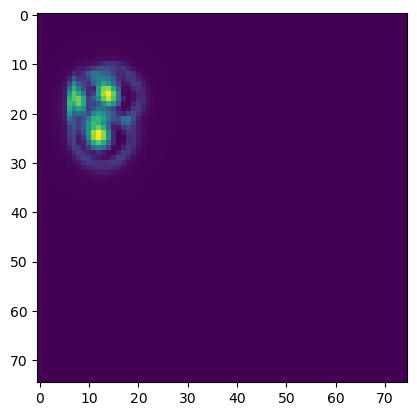

In [27]:
plt.imshow(state.TH[:][0, 4,:,:])

In [26]:
import matplotlib.pyplot as plt

In [22]:
for var in state['state_vector']['xyz3d']:
    print(N.shape(state[var][:]))

(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)


In [2]:
def write_CM1_ens(ens, writeEns=False, overwrite=False, writeFcstMean=False, writeAnalMean=False, HF=None):

  """
    Writes out all 3D variables back to the CM1v18 restart netCDF4 files.  
    
    If writeEns == True, write out the entire ensemble back to disk.
    
    If overwrite == True, overwrite the CM1 restart files that were read into the ens data structure.  The 'prior' 
       forecast data will be lost, hence its almost never a good idea to set this to True, unless you are 
       desparate for disk space or something else that is not normal. 
    
    If overwrite == False, the original restart files are copied from XXXXX_rst_000XXX.nc to XXXXX_prior_000XXX.nc
       in each member directory.  Then the ens state data are written back into the XXXXX_rst_000XXX.nc files.  
       Therefore the "prior" files hold the forecasts, and the "rst" files are the new analysis states.

    If writeAnalMean == True, then place a file into the "member000" directory called XXXXX_post_000XXX.nc
        
    If writeFcstMean == True, then place a file into the "member000" directory called XXXXX_prior_000XXX.nc
        
    If the state vector does not include a variable, none is written to the netCDF file.  
    
    Example:  If you choose not to read in a variable, say, number concentration of ice, then it will not be
              available in the state vectors array to be written out (either as the fcst/analysis mean, etc).
              
    Also, only rank-3 state vectors are currently copied.  The rank-0 (scalars like NX) and rank-1 (1D arrays like ZC)
          are assumed to be already in the file when it was created.
  """

  t0 = timer()

#-----------------------------------------------------------------------------------------      
# If OVERWRITE....

  f = ncdf.Dataset(ens.files[0], "r")
  time = f.variables['time'][:]
  f.close()
  del(f)

  if writeEns == True:
  
    time_index = ens.time_index
    t_index    = time_index

    print("\n ==> WRITE_CM1_ENS:  Writing ensemble into time_index %d at time %d" % (time_index, time[time_index]))

    if overwrite == True:

      print("\n ==> WRITE_CM1_ENS: WARNING:  Overwriting CM1 restart file, no fcst restart files will be saved")

    else:

      for file in ens.files:

# Here we take the current forecast file and copy it to a new netCDF file with a slightly different name

        #cmd = "cp %s %s" % (file, file.replace("_rst_", "_prior_"))
        cmd = "cp %s %s" % (file, file.replace("rst_", "_prior_")) #new version
        os.system(cmd)

      print("\n ==> WRITE_CM1_ENS:  CM1 prior files creation completed")

#-----------------------------------------------------------------------------------------      
# Automatically compute C-grid velocities from stored A-grid velocities - this is automatic now

    ens_CM1_A2C(ens)
    
#-----------------------------------------------------------------------------------------      
# Writing out xyz3d to each ensemble member

    if HF == None:
        files = ens.files
    else:
        files = ens.files[HF::2]
        print(files)
        print("\n ==> WRITE_CM1_ENS HF on, starting at  %d" % (HF))
        print("\n ==> WRITE_CM1_ENS HF on, First file to writeback  %s" % (files[0] ))
        print("\n ==> WRITE_CM1_ENS HF on, Last file to writeback:  %s" % (files[-1]))

    for n, file in enumerate(files):

      f = ncdf.Dataset(file, "r+")

      for key in ens.state_vector['xyz3d']:
      
        if ens.state_vector[key]['writeback']:
      
          if key == "U":        
            f[ens.state_vector[key]['name']][:,:,:] = fstate.u[n,:,:,:]
      
          elif key == "V":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.v[n,:,:,:]

          elif key == "W":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.w[n,:,:,:]

          else:          
            f[ens.state_vector[key]['name']][:,:,:] = ens.__dict__[key][n,:,:,:]
   
        else:
          if debug_io:
            print("\n ==> WRITE_CM1_ENS:  Did not writeback variable %s to netCDF file" % key)
          
      #f.sync()
      f.close()
      del(f)

      if debug_io:
        print("\n ==> WRITE_CM1_ENS:  Closed file %s" % files[n])

# End writing out ensemble files to CM1 restart files.      
#-----------------------------------------------------------------------------------------            
# IF writeFcstMean == True or writeAnalMean == True, write out mean state...

  if writeFcstMean == True or writeAnalMean == True:

# if user forgot to create the mean, do it here

    if ens.addmean != 1:
      ens_CM1_mean(ens)
      ens.addmean = 1

# Does a member000 directory exist for mean analyses?

    member000_dir = os.path.join(ens.experiment['base_path'],"member000")

    if os.path.isdir(member000_dir) != True:
      os.mkdir(member000_dir)

    if writeAnalMean == True:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_post_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_post_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out posterior ensemble mean into %s" % (meanfile))
    else:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_prior_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_prior_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out prior ensemble mean into %s" % (meanfile))
    
    cmd = "cp -f %s %s" % (ens.files[0], meanfile)
    os.system(cmd)

    f = ncdf.Dataset(meanfile, format='NETCDF4')

    for key in ens.state_vector["xyz3d"]: 
      
      if key in f.variables:

        if key == "U":        
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.u[ens.ne,:,:,:]
      
        elif key == "V":  
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.v[ens.ne,:,:,:]

        elif key == "W":  
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.w[ens.ne,:,:,:]

        else:          
          f[ens.state_vector[key]['name']][0,:,:,:] = ens.__dict__[key][ens.ne,:,:,:]
        
    f.sync()
    f.close()

    print("\n ==> WRITE_CM1_ENS:  Closed file %s" % meanfile)

# End writing out full ensemble forecast or analysis files.      
#---------------------------------------------------------------------------------------------------
#
  if time_all:  print("\n ==> Wallclock time to write out fcst/anal to files:", round(timer() - t0, 3), " sec")

  return


In [7]:
myDTstring = '2003,5,8,20,45,0'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)

files, myDT = FindRestartFiles(exper, myDTstring, ret_exp=False,)
state = read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens_CM1_coords(state)
#ens_check(files, state)

ens_IC_pertUV(state, writeout=False)
ens_IC_pert_from_box(state, plot=False, writeout=False)
write_CM1_ens(state, writeEns=True, overwrite=False)

# for n, file in enumerate(files[0:1]):


#       f = ncdf.Dataset(file, "r")
    
#       for key in state.state_vector['xyz3d']:
      
#         if state.state_vector[key]['writeback']:
      
#           if key == "U":        
#             f[state.state_vector[key]['name']][:,:,:] = fstate.u[n,:,:,:]
      
#           elif key == "V":  
#             f[state.state_vector[key]['name']][:,:,:] = fstate.v[n,:,:,:]

#           elif key == "W":  
#             f[state.state_vector[key]['name']][:,:,:] = fstate.w[n,:,:,:]

#           else:          
#             f[state.state_vector[key]['name']][:,:,:] = state.__dict__[key][n,:,:,:]
   
#         else:
#           if debug_io:
#             print("\n ==> WRITE_CM1_ENS:  Did not writeback variable %s to netCDF file" % key)
          


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 20:45:00

 ==> FindRestartFile:  Found time 300 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000001.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 20:45:00 



ValueError: could not broadcast input array from shape (52,51,75,76) into shape (51,75,76)

In [3]:
f = ncdf.Dataset(file, "r")

In [5]:
key="U"
f[state.state_vector[key]['name']]

<class 'netCDF4._netCDF4.Variable'>
float32 ua(time, nk, nj, nip1)
    long_name: west-east velocity (at u points)
    units: m/s
unlimited dimensions: time
current shape = (1, 51, 75, 76)
filling on, default _FillValue of 9.969209968386869e+36 used